# **Cosine Similarity Between Graphs**

## 📦 **Package Import**

In [1]:
# python
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import sys
import os
from pathlib import Path
import re

# PepProtGraphAnalyzer framework
sys.path.append('/home/jovyan/work/PepProtGraphAnalyzer')
from PepProtGraphAnalyzer.module.notebook import NotebookApp
from PepProtGraphAnalyzer.util.plotting import boxplot, scatter

app = NotebookApp('.env.jupyter.StarPep')
paths = app.paths()

[2025-09-23 19:13:45,882] WARNING [data_validator.py:87] Sequences with non-natural amino acids were excluded. See: /home/jovyan/work/output/out_paper/Starpep/Log/Sequences with Non-Natural Amino Acids.csv
[2025-09-23 19:13:53,371] INFO [notebook.py:70] Setting:
dataset_path: /home/jovyan/work/PepProtGraphAnalyzer/dataset/StarPep/StarPep.csv
pdb_path: /home/jovyan/work/PepProtGraphAnalyzer/dataset/StarPep/ESMFold_pdbs
notebook_output_path: /home/jovyan/work/output/out_paper/Starpep
sequence_analysis_path: /home/jovyan/work/PepProtGraphAnalyzer/output/results_with_seq_10_to_100/StarPep/2025-04-07T19.42.20-Sequence_Analyzer
graph_analysis_path: /home/jovyan/work/PepProtGraphAnalyzer/output/results_with_seq_10_to_100/StarPep/2025-04-07T19.56.31-Graph_Analyzer
min_seq_len: 10
max_seq_len: 100


## 📊 **Data Analysis**

### **Data**

In [2]:
data = pd.read_csv(app.graph_analysis['graph_similarity'])

data["distance_interval_1"] = data["distance_function_1"] + " " + data["interval_1"].astype(str)
data["distance_interval_2"] = data["distance_function_2"] + " " + data["interval_2"].astype(str)
data["distance_interval_comb"] = data["distance_interval_1"] + " - " + data["distance_interval_2"].astype(str)

statistics = pd.read_csv(
    app.graph_analysis['graph_similarity_summary'].with_name(
        app.graph_analysis['graph_similarity_summary'].name + "-cosine_similarity.csv"
    )
)

statistics["distance_interval_1"] = statistics["distance_function_1"] + " " + statistics["interval_1"].astype(str)
statistics["distance_interval_2"] = statistics["distance_function_2"] + " " + statistics["interval_2"].astype(str)
statistics["distance_interval_comb"] = statistics["distance_interval_1"] + " - " + statistics["distance_interval_2"].astype(str)

data[["sequence", "distance_interval_comb", "cosine_similarity"]].head()

,sequence,distance_interval_comb,cosine_similarity
0,GIGAVLKVLTTGLPALISWIKRKRQQ,"euclidean (0, 10.2836) - euclidean (0, 16.6132)",0.759178
1,GIGAVLKVLTTGLPALISWIKRKRQQ,"euclidean (0, 10.2836) - euclidean (0, 26.242)",0.713840
2,GIGAVLKVLTTGLPALISWIKRKRQQ,"euclidean (0, 10.2836) - canberra (0, 0.6155)",0.848112
3,GIGAVLKVLTTGLPALISWIKRKRQQ,"euclidean (0, 10.2836) - canberra (0, 1.0142)",0.807440
4,GIGAVLKVLTTGLPALISWIKRKRQQ,"euclidean (0, 10.2836) - canberra (0, 1.4712)",0.759417


### **Distance Intervals**

In [3]:
unique_values = pd.Series(pd.concat([statistics["distance_interval_1"], statistics["distance_interval_2"]]).unique()).sort_values()
display(Markdown("\n".join(f"- {val}" for val in unique_values)))

- angular_separation (0, 0.018)
- angular_separation (0, 0.0654)
- angular_separation (0, 0.1799)
- bhattacharyya (0, 1.5158)
- bhattacharyya (0, 2.4304)
- bhattacharyya (0, 3.6452)
- canberra (0, 0.6155)
- canberra (0, 1.0142)
- canberra (0, 1.4712)
- clark (0, 0.4161)
- clark (0, 0.6813)
- clark (0, 0.983)
- euclidean (0, 10.2836)
- euclidean (0, 16.6132)
- euclidean (0, 26.242)
- lance_williams (0, 0.1789)
- lance_williams (0, 0.3041)
- lance_williams (0, 0.466)
- soergel (0, 0.3035)
- soergel (0, 0.4664)
- soergel (0, 0.6357)

### **Statistics**

In [4]:
columns = ["distance_interval_comb", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics.reset_index(drop=True)[columns])

,distance_interval_comb,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"angular_separation (0, 0.018) - angular_separa...",34605,-0.943026,0.660786,0.334436,0.609975,0.783927,0.881692,0.999321,-1.639632,5.123651
1,"angular_separation (0, 0.018) - angular_separa...",34605,-0.889494,0.622474,0.335352,0.543899,0.725813,0.857010,0.997599,-1.544777,5.010501
2,"angular_separation (0, 0.0654) - angular_separ...",34636,-0.786599,0.810041,0.262808,0.803171,0.890154,0.953104,1.000000,-2.654897,9.531186
3,"bhattacharyya (0, 1.5158) - angular_separation...",34605,-0.923321,0.668758,0.301881,0.629015,0.787847,0.851596,1.000000,-1.965236,6.778850
4,"bhattacharyya (0, 1.5158) - angular_separation...",34636,-0.903570,0.768766,0.172015,0.743797,0.806253,0.859934,0.999218,-3.167161,17.145962
...,...,...,...,...,...,...,...,...,...,...,...
205,"soergel (0, 0.6357) - angular_separation (0, 0...",34636,-0.735760,0.825086,0.199032,0.795538,0.885474,0.931819,1.000000,-3.198671,14.800583
206,"soergel (0, 0.6357) - angular_separation (0, 0...",34636,-0.483765,0.891224,0.168807,0.897381,0.930489,0.954526,1.000000,-4.438285,23.663169
207,"soergel (0, 0.6357) - bhattacharyya (0, 1.5158)",34636,-0.618761,0.773659,0.137135,0.724221,0.790832,0.851780,0.987809,-3.168582,19.765531
208,"soergel (0, 0.6357) - bhattacharyya (0, 2.4304)",34636,-0.394695,0.900570,0.058787,0.871602,0.905853,0.940719,1.000000,-2.834003,39.864391


### **Analysis of Graph Similarity Distribution (*per Distance Function*)**

#### **Euclidean**

##### *25th Percentile*

<br>*Cosine Similarity Between Graphs (Euclidean 25th Percentile)*

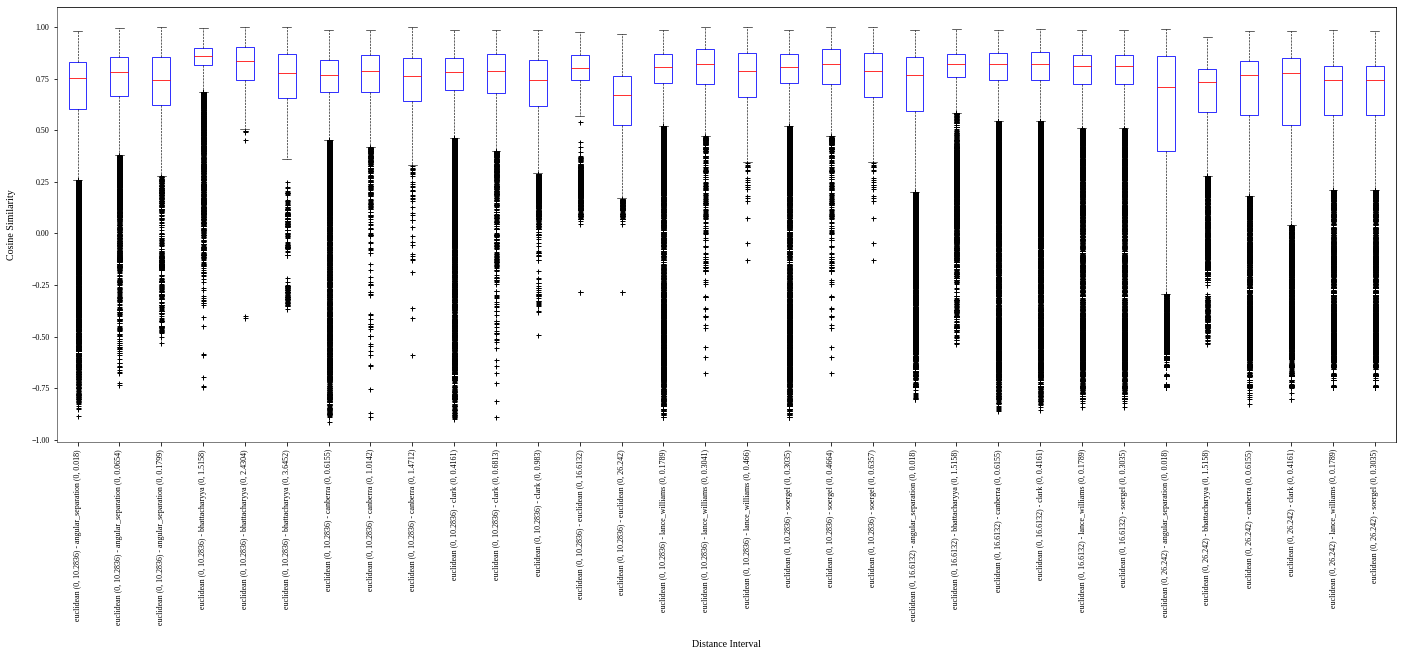

<br>*Cosine Similarity Between Graphs (Euclidean 25th Percentile) -without outliter*

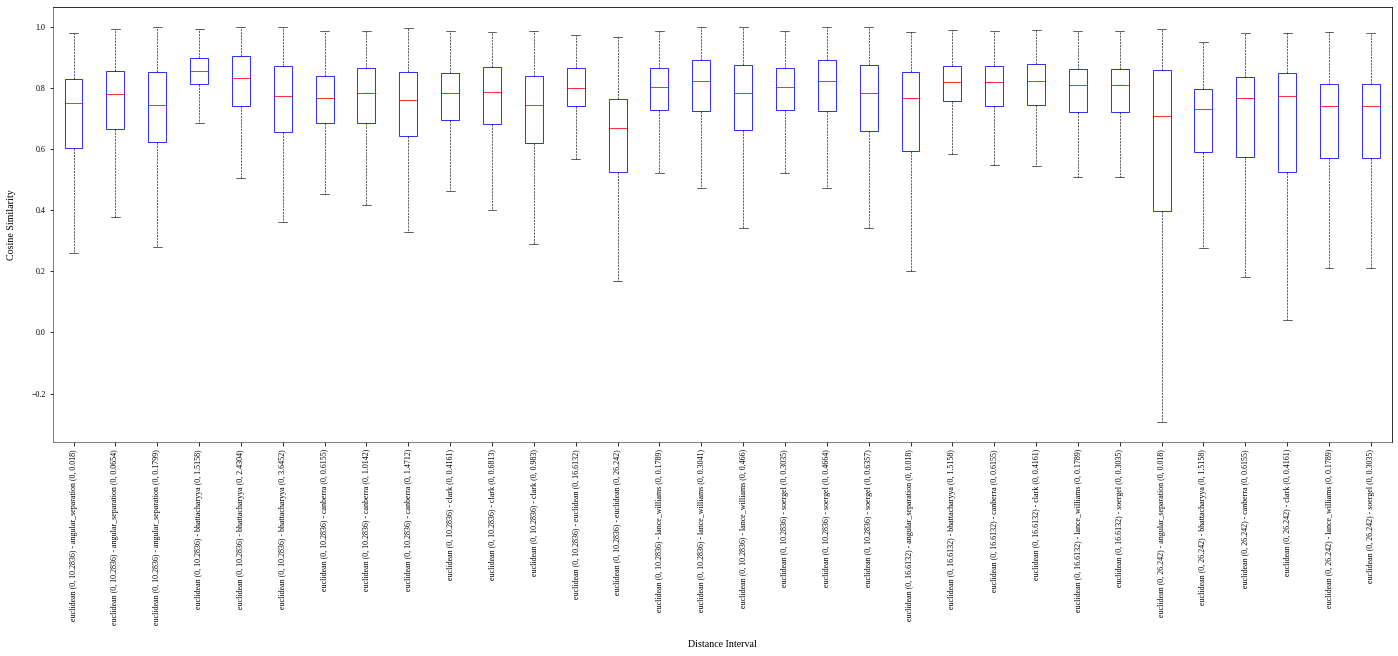

In [5]:
distance_intervals = [
    'euclidean (0, 10.2836)',
    'angular_separation (0, 0.018)',
    'bhattacharyya (0, 1.5158)',
    'canberra (0, 0.6155)',
    'clark (0, 0.4161)',
    'lance_williams (0, 0.1789)',
    'soergel (0, 0.3035)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('euclidean', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Euclidean 25th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (eu_p25_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Euclidean 25th Percentile) -without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (eu_p25_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

##### *50th Percentile*

<br>*Cosine Similarity Between Graphs (Euclidean 50th Percentile)*

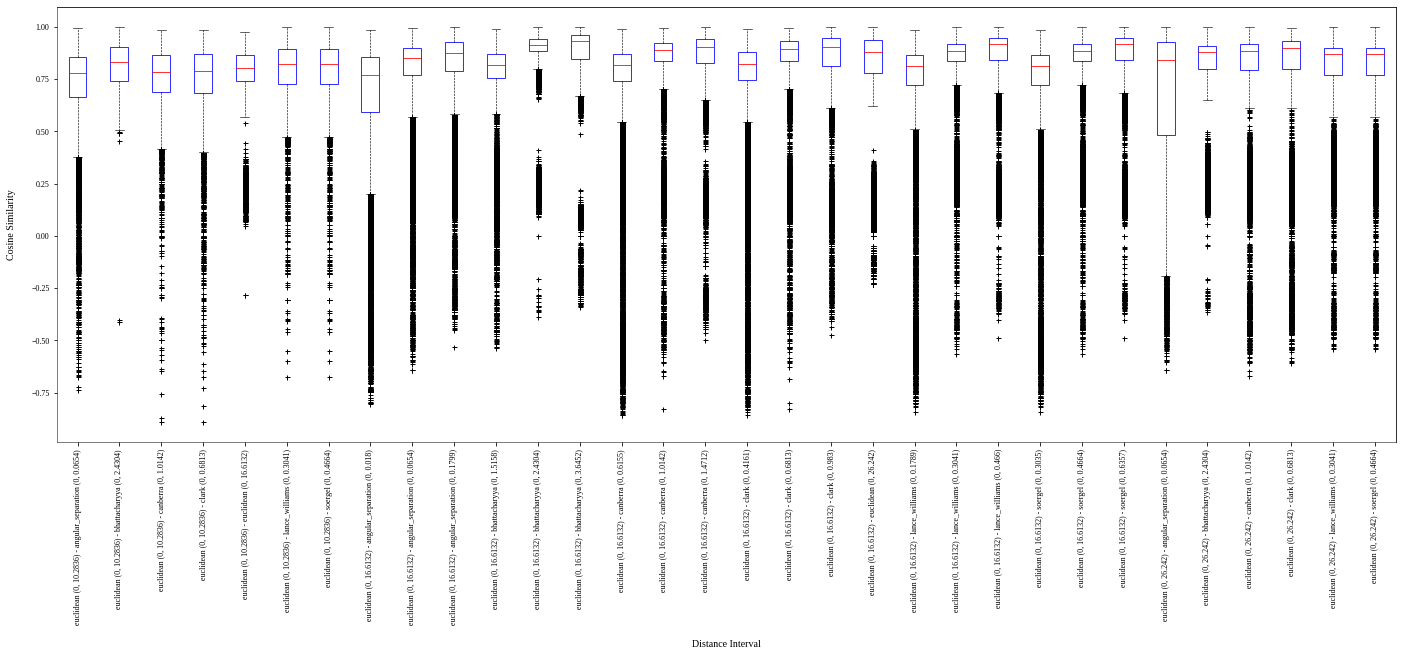

<br>*Cosine Similarity Between Graphs (Euclidean 50th Percentile) - without outliter*

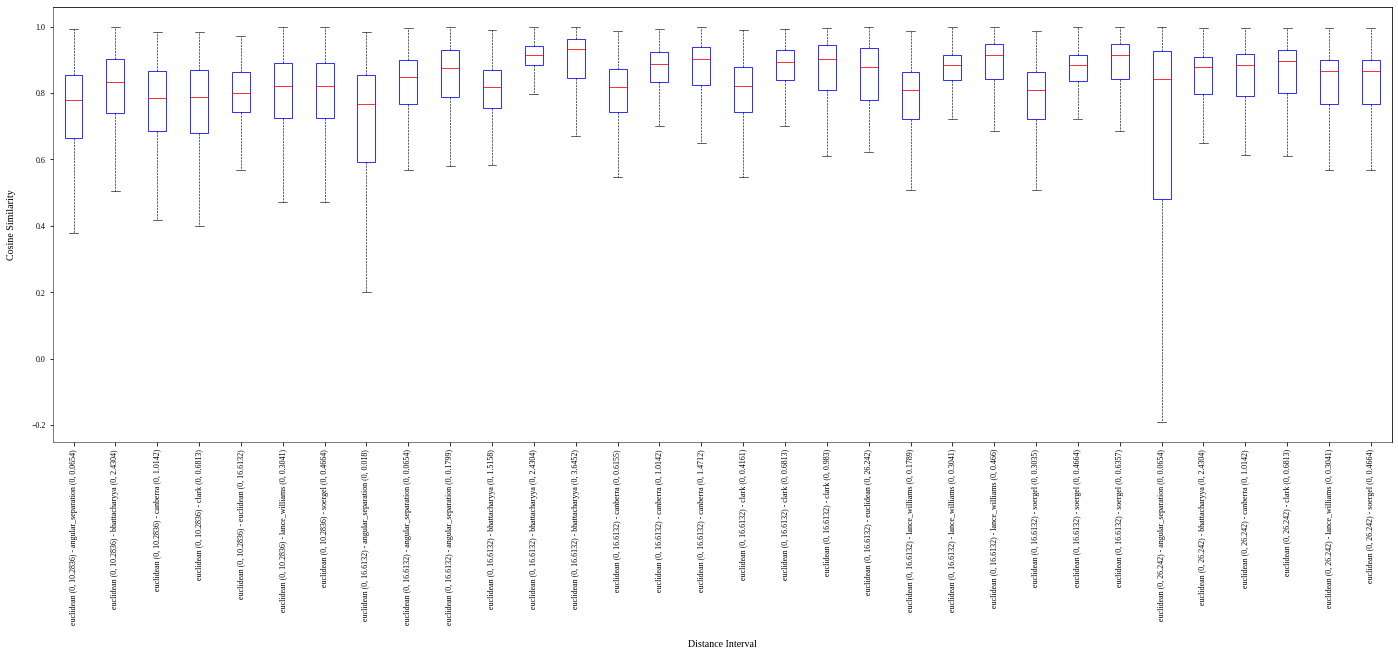

In [6]:
distance_intervals = [
    'euclidean (0, 16.6132)',
    'angular_separation (0, 0.0654)',
    'bhattacharyya (0, 2.4304)',
    'canberra (0, 1.0142)',
    'clark (0, 0.6813)',
    'lance_williams (0, 0.3041)',
    'soergel (0, 0.4664)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('euclidean', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Euclidean 50th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (eu_p50_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Euclidean 50th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (eu_p50_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

##### *75th Percentile*

<br>*Cosine Similarity Between Graphs (Euclidean 75th Percentile)*

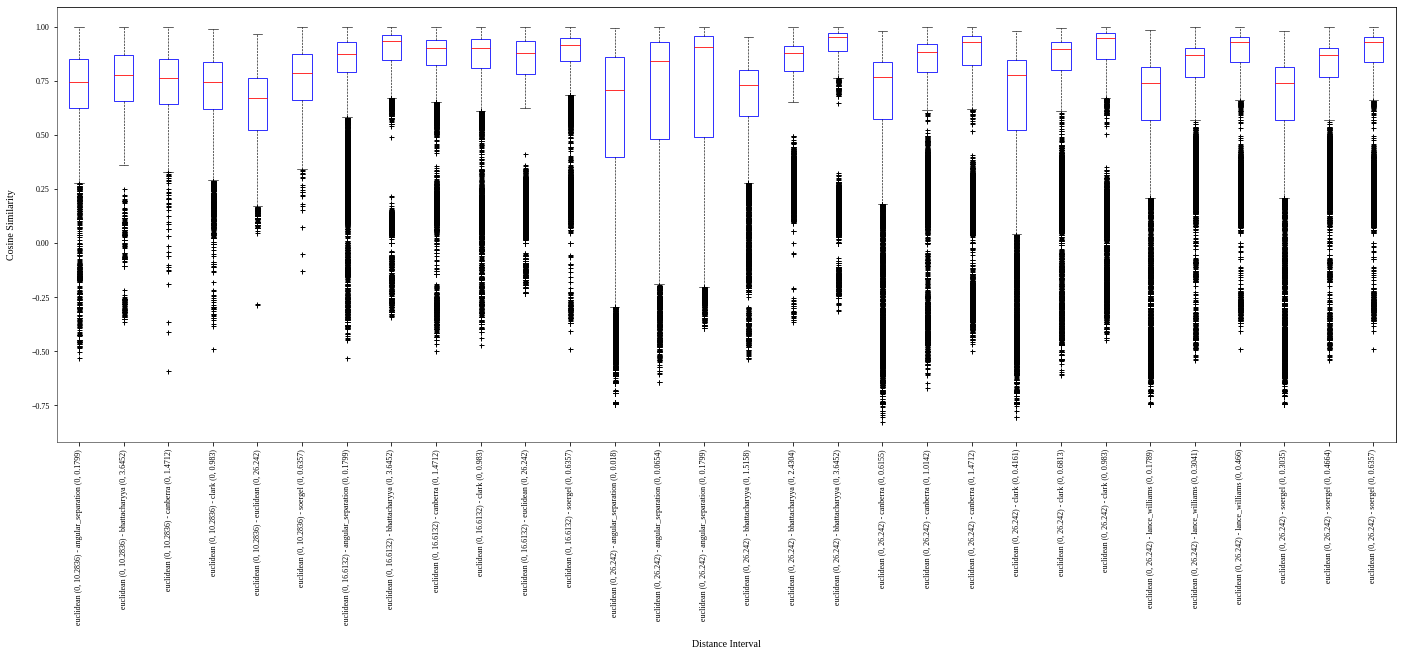

<br>*Cosine Similarity Between Graphs (Euclidean 75th Percentile) - without outliter*

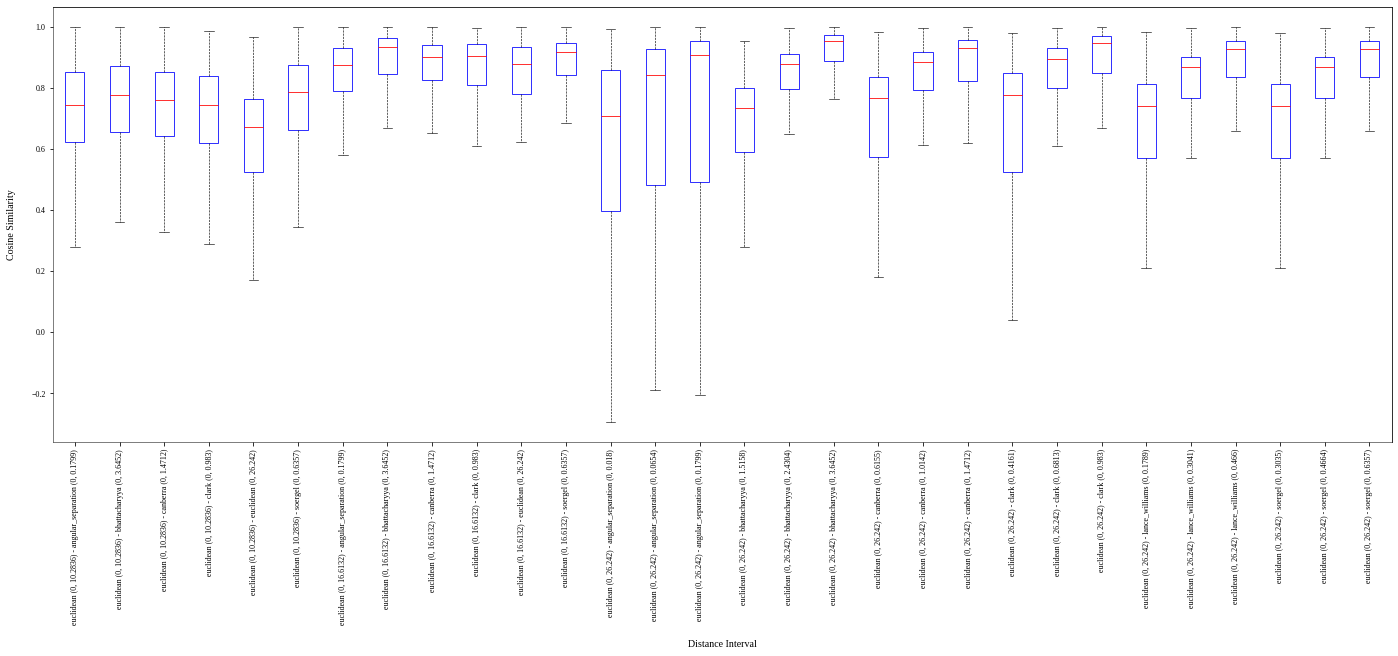

In [7]:
distance_intervals = [
    'euclidean (0, 26.242)',
    'angular_separation (0, 0.1799)',
    'bhattacharyya (0, 3.6452)',
    'canberra (0, 1.4712)',
    'clark (0, 0.983)',
    'euclidean (0, 466)',
    'soergel (0, 0.6357)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('euclidean', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Euclidean 75th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (eu_p75_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Euclidean 75th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (eu_p75_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

#### **Bhattacharyya**

##### *25th Percentile*

<br>*Cosine Similarity Between Graphs (Bhattacharyya 25th Percentile)*

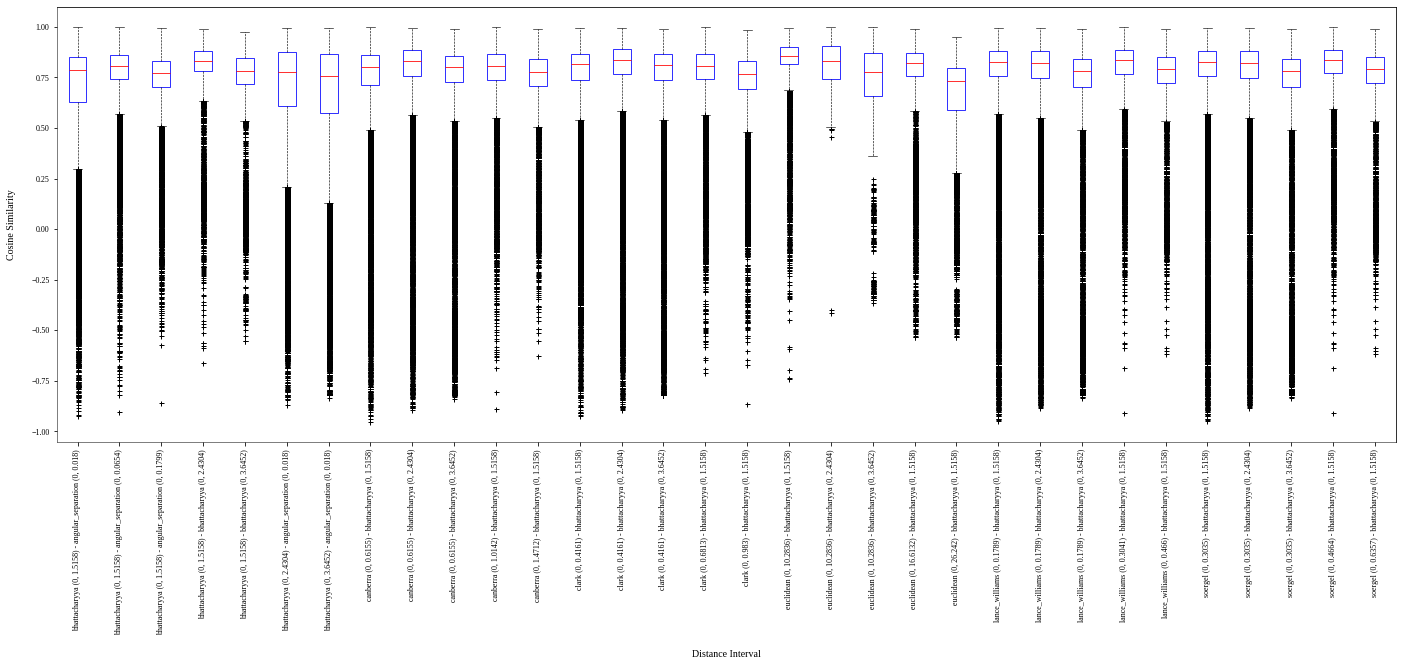

<br>*Cosine Similarity Between Graphs (Bhattacharyya 25th Percentile) - without outliter*

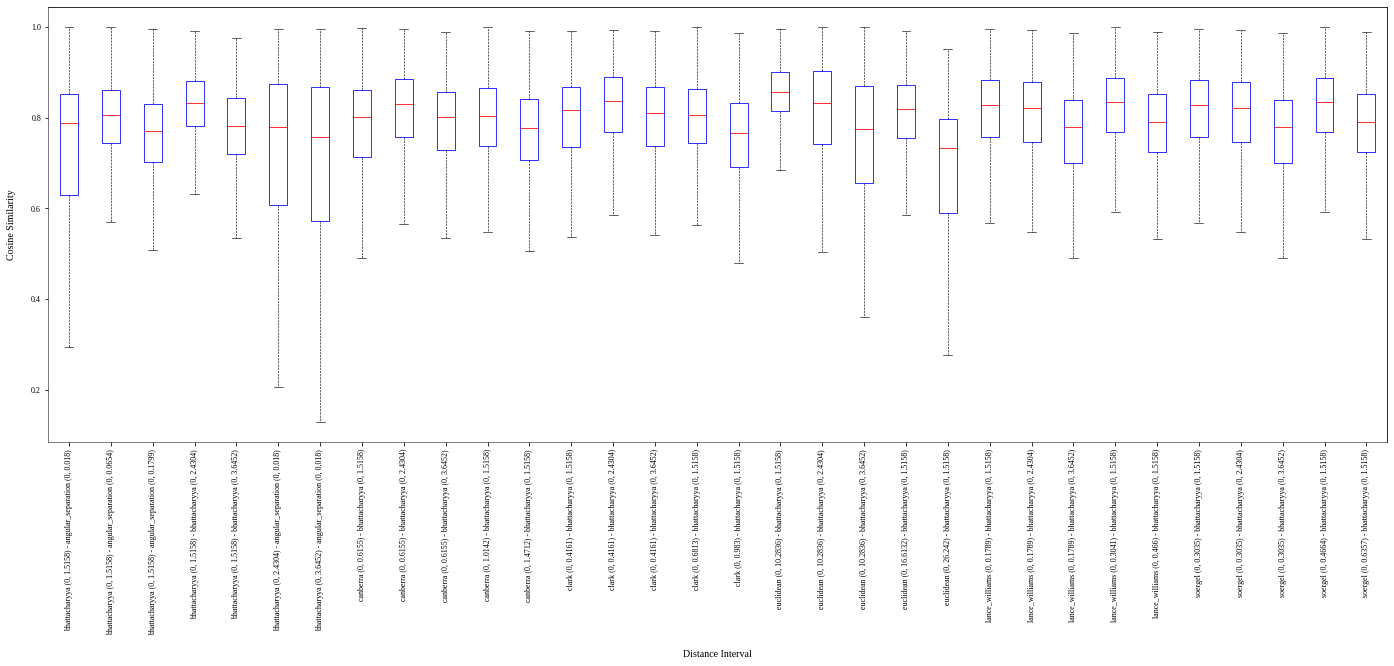

In [8]:
distance_intervals = [
    'euclidean (0, 10.2836)',
    'angular_separation (0, 0.018)',
    'bhattacharyya (0, 1.5158)',
    'canberra (0, 0.6155)',
    'clark (0, 0.4161)',
    'lance_williams (0, 0.1789)',
    'soergel (0, 0.3035)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('bhattacharyya', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Bhattacharyya 25th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (ba_p25_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Bhattacharyya 25th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (ba_p25_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

##### *50th Percentile*

<br>*Cosine Similarity Between Graphs (Bhattacharyya 50th Percentile)*

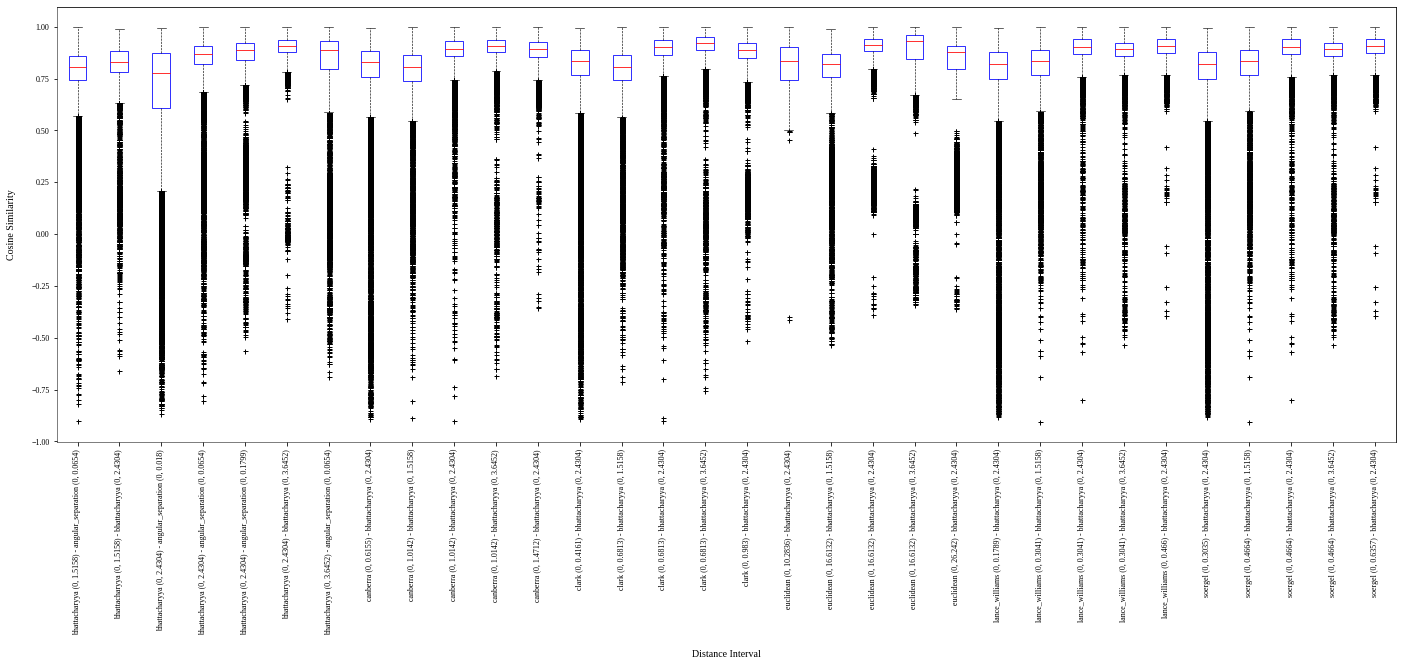

<br>*Cosine Similarity Between Graphs (Bhattacharyya 50th Percentile) - without outliter*

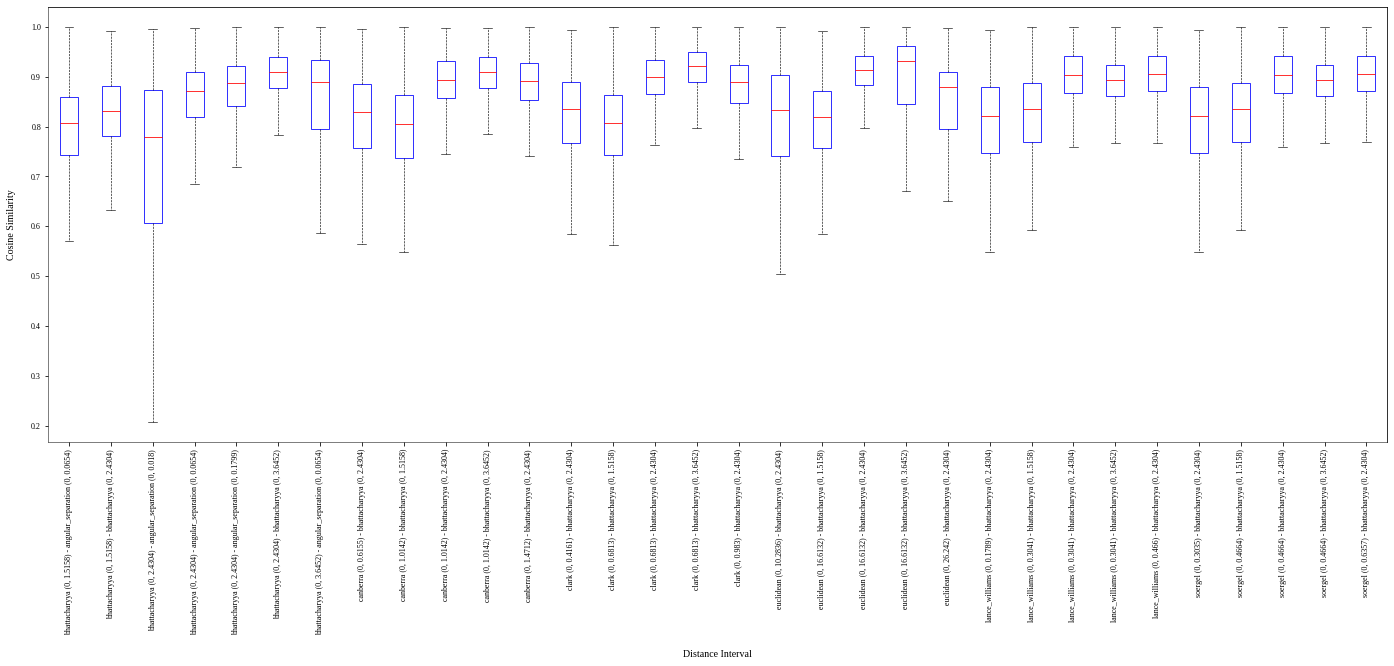

In [9]:
distance_intervals = [
    'euclidean (0, 16.6132)',
    'angular_separation (0, 0.0654)',
    'bhattacharyya (0, 2.4304)',
    'canberra (0, 1.0142)',
    'clark (0, 0.6813)',
    'lance_williams (0, 0.3041)',
    'soergel (0, 0.4664)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('bhattacharyya', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Bhattacharyya 50th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (ba_p50_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Bhattacharyya 50th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (ba_p50_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

##### *75th Percentile*

<br>*Cosine Similarity Between Graphs (Bhattacharyya 75th Percentile)*

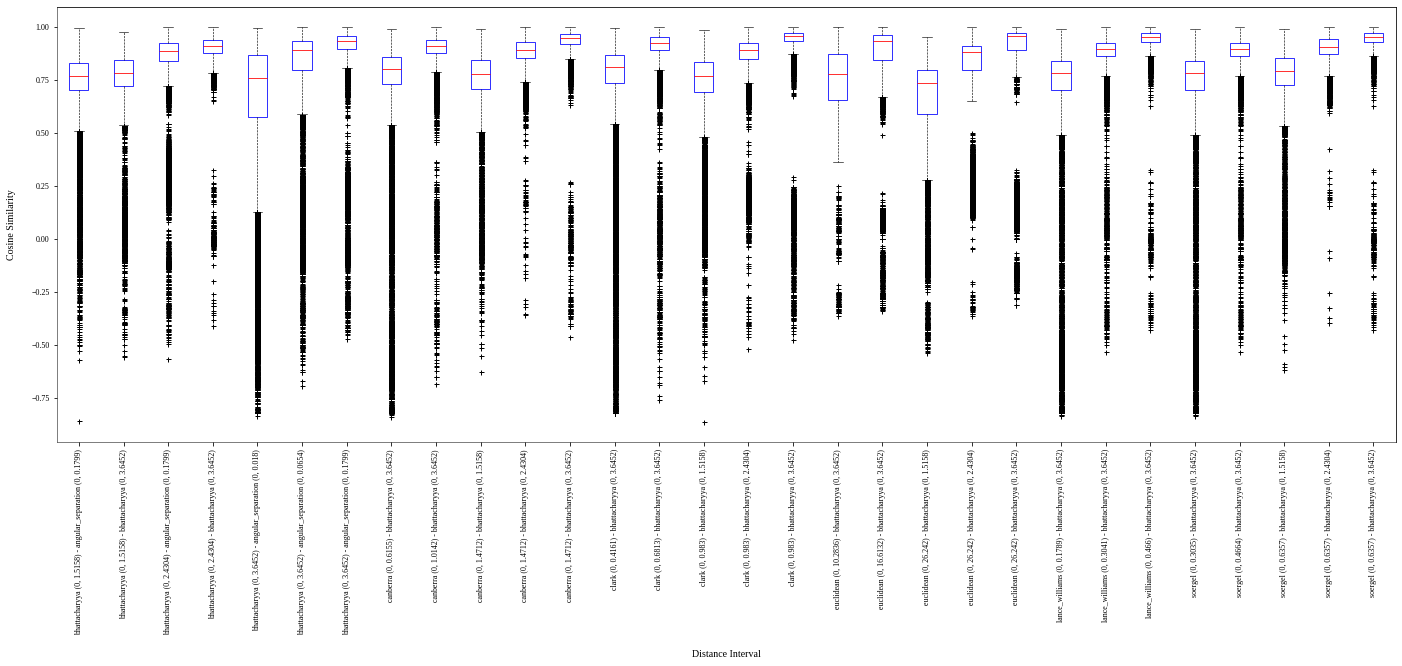

<br>*Cosine Similarity Between Graphs (Bhattacharyya 75th Percentile) - without outliter*

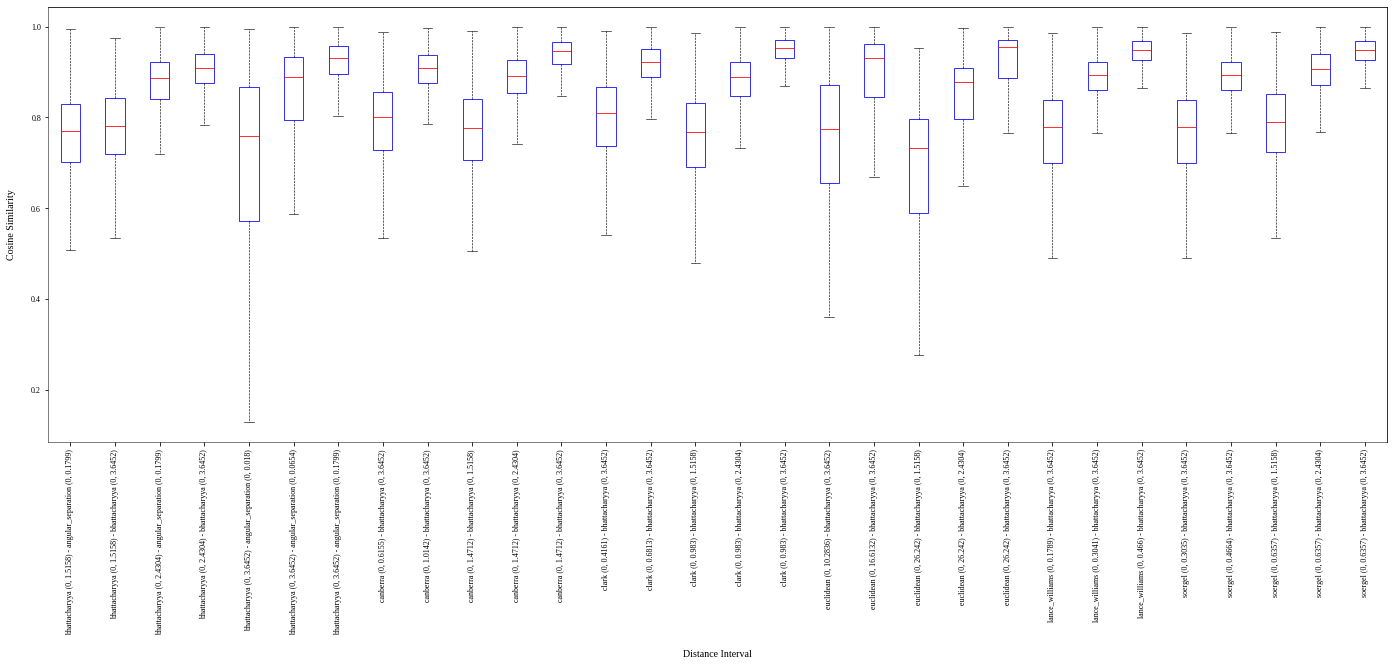

In [10]:
distance_intervals = [
    'euclidean (0, 26.242)',
    'angular_separation (0, 0.1799)',
    'bhattacharyya (0, 3.6452)',
    'canberra (0, 1.4712)',
    'clark (0, 0.983)',
    'euclidean (0, 466)',
    'soergel (0, 0.6357)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('bhattacharyya', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Bhattacharyya 75th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (ba_p75_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Bhattacharyya 75th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (ba_p75_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

#### **Canberra**

##### *25th Percentile*

<br>*Cosine Similarity Between Graphs (Canberra 25th Percentile)*

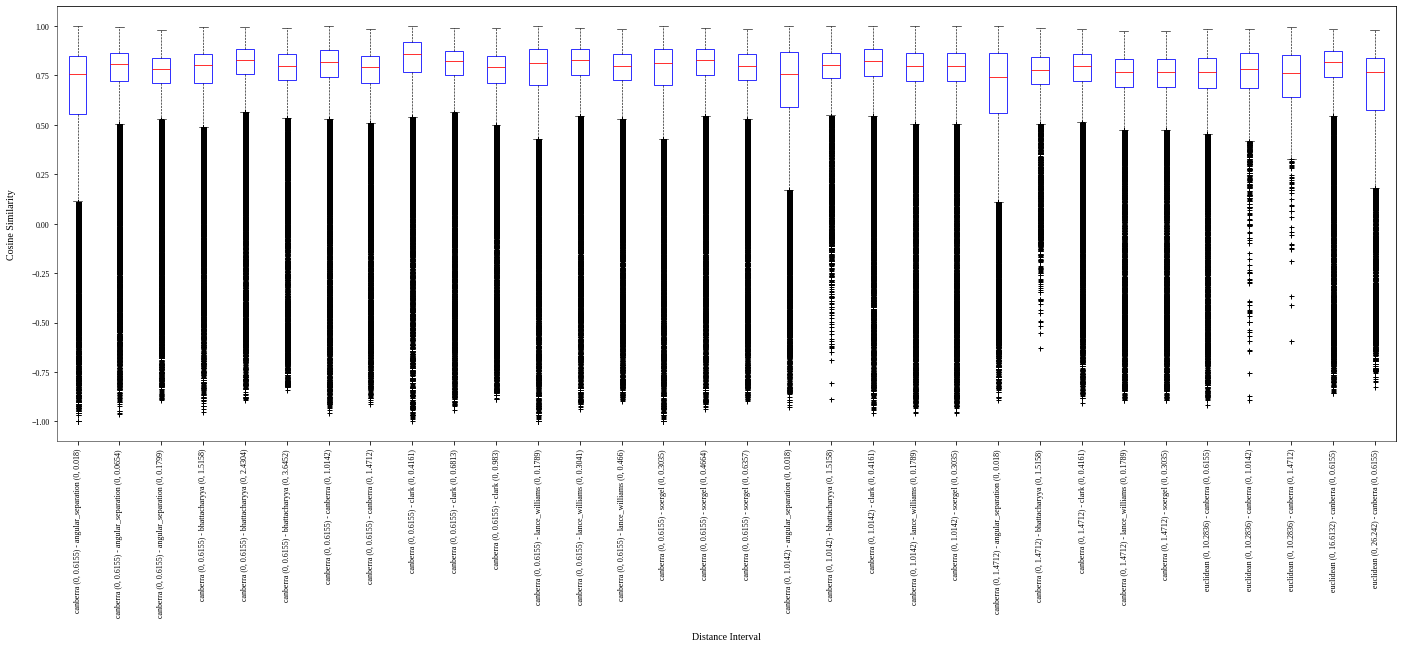

<br>*Cosine Similarity Between Graphs (Canberra 25th Percentile) - without outliter*

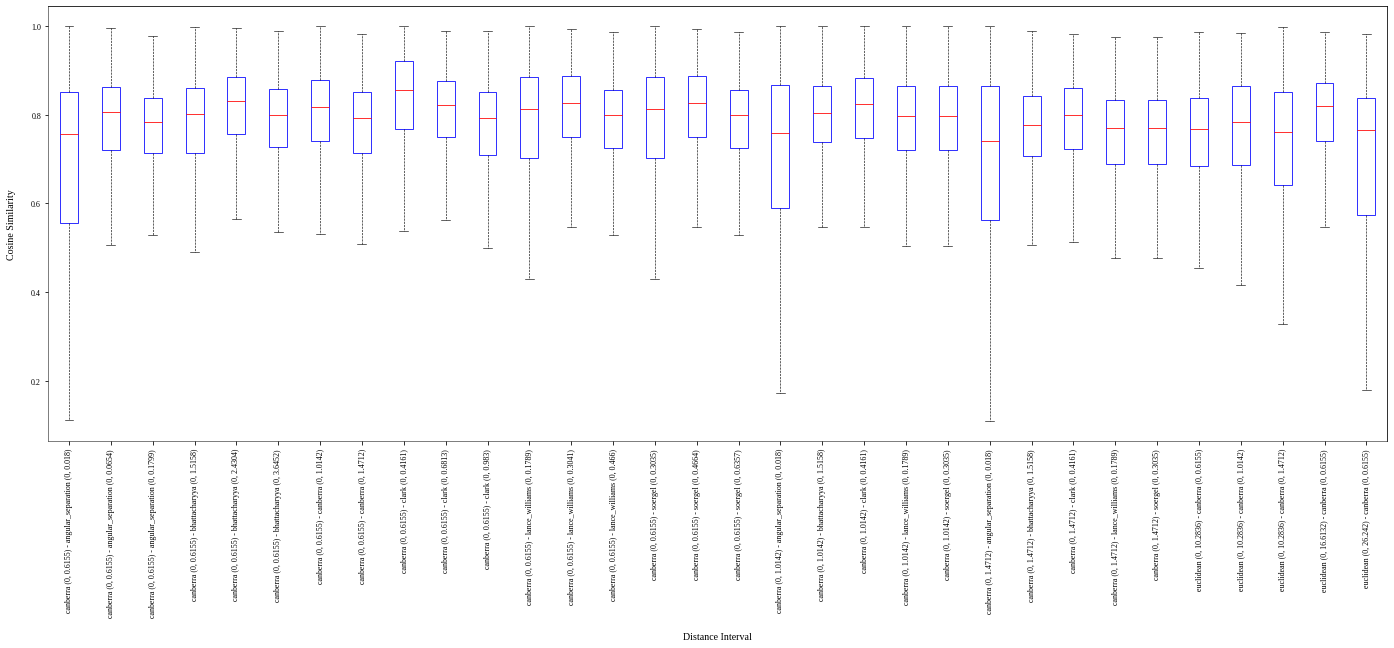

In [11]:
distance_intervals = [
    'euclidean (0, 10.2836)',
    'angular_separation (0, 0.018)',
    'bhattacharyya (0, 1.5158)',
    'canberra (0, 0.6155)',
    'clark (0, 0.4161)',
    'lance_williams (0, 0.1789)',
    'soergel (0, 0.3035)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('canberra', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
output = paths['graph_similarity_path'].joinpath("boxplot-similarity-ca_p25")
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Canberra 25th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (ca_p25_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Canberra 25th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (ca_p25_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

##### *50th Percentile*

<br>*Cosine Similarity Between Graphs (Canberra 50th Percentile)*

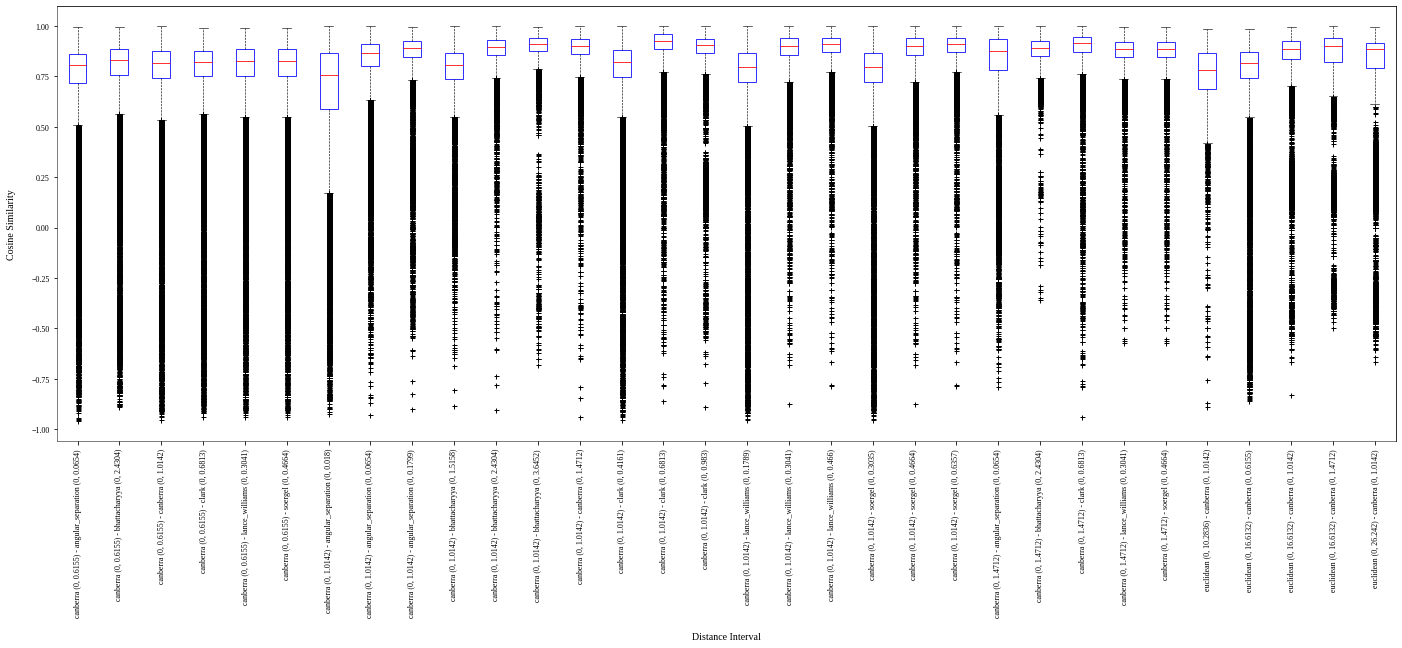

<br>*Cosine Similarity Between Graphs (Canberra 50th Percentile) - without outliter*

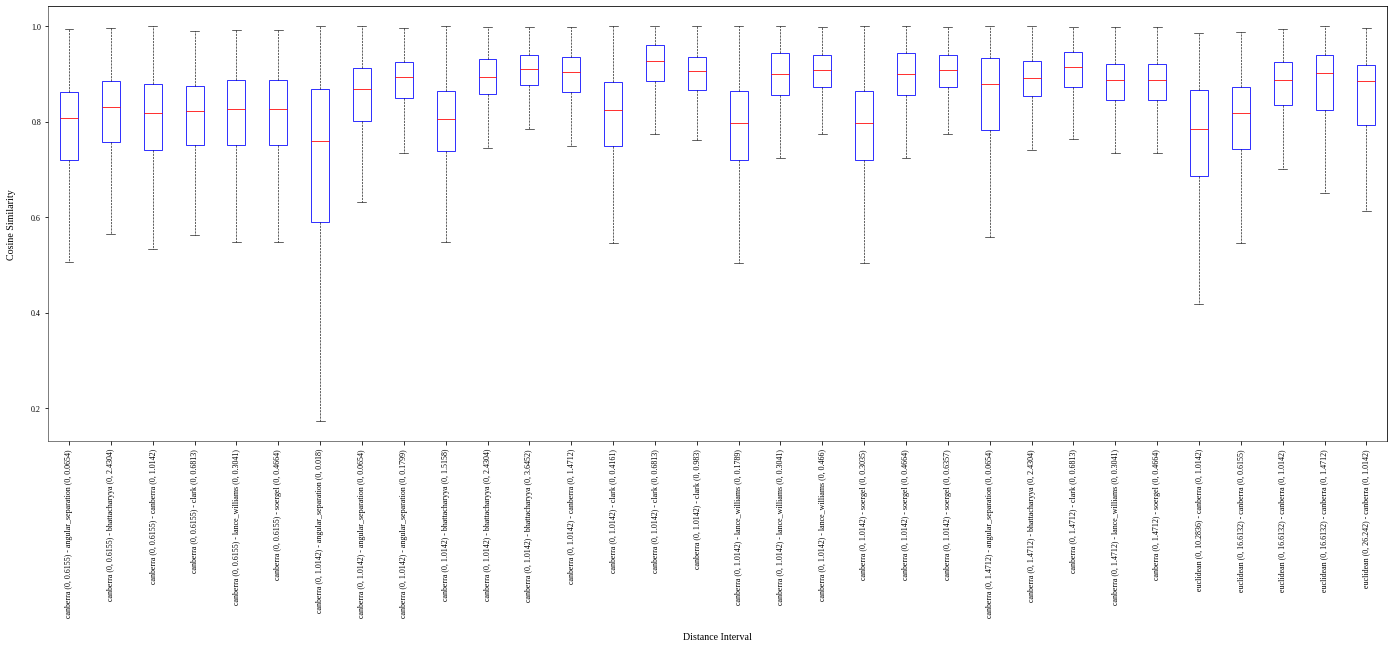

In [12]:
distance_intervals = [
    'euclidean (0, 16.6132)',
    'angular_separation (0, 0.0654)',
    'bhattacharyya (0, 2.4304)',
    'canberra (0, 1.0142)',
    'clark (0, 0.6813)',
    'lance_williams (0, 0.3041)',
    'soergel (0, 0.4664)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('canberra', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Canberra 50th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (ca_p50_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Canberra 50th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (ca_p50_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

##### *75th Percentile*

<br>*Cosine Similarity Between Graphs (Canberra 75th Percentile)*

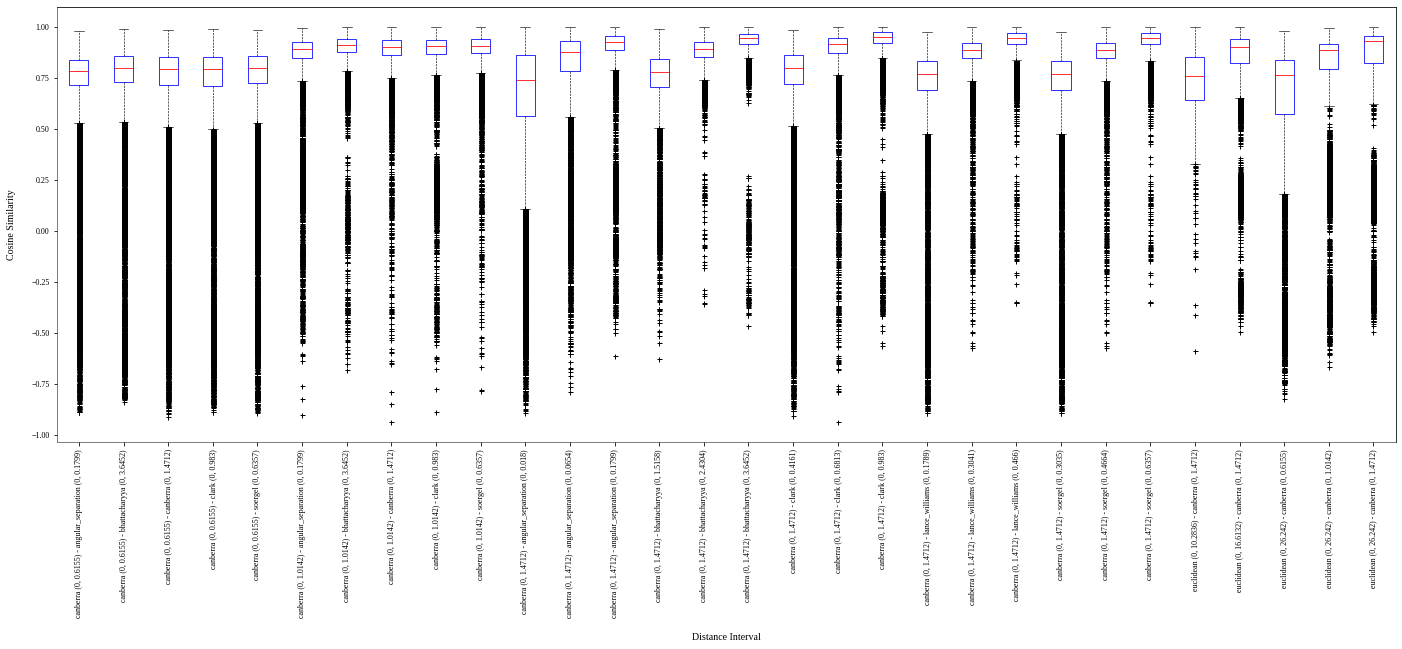

<br>*Cosine Similarity Between Graphs (Canberra 75th Percentile) - without outliter*

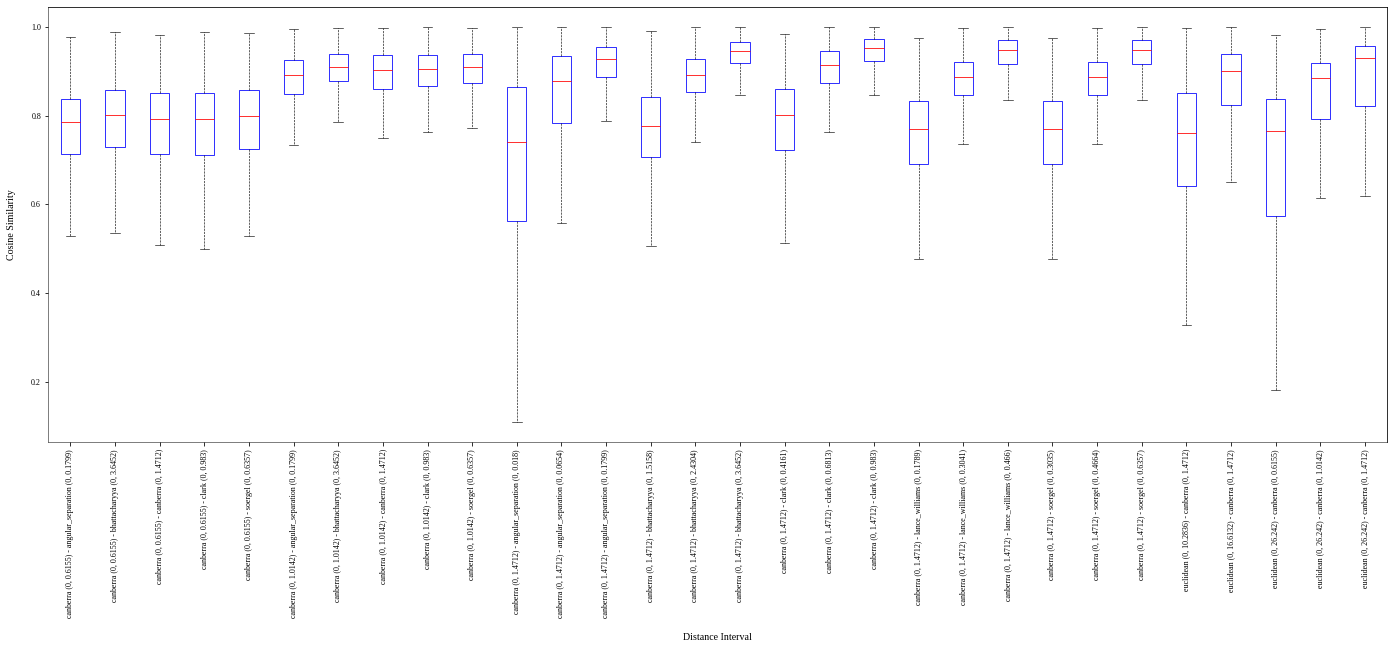

In [13]:
distance_intervals = [
    'euclidean (0, 26.242)',
    'angular_separation (0, 0.1799)',
    'bhattacharyya (0, 3.6452)',
    'canberra (0, 1.4712)',
    'clark (0, 0.983)',
    'euclidean (0, 466)',
    'soergel (0, 0.6357)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('canberra', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Canberra 75th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (ca_p75_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Canberra 75th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (ca_p75_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

#### **Clark**

##### *25th Percentile*

<br>*Cosine Similarity Between Graphs (Clark 25th Percentile)*

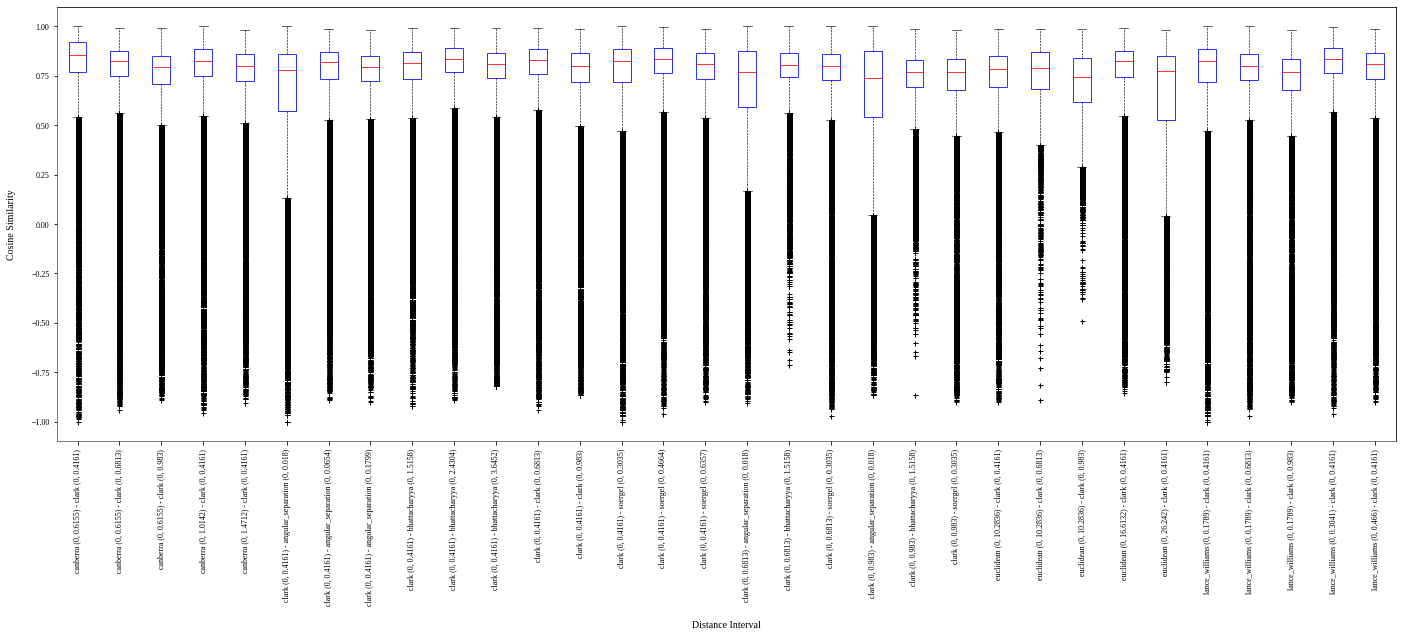

<br>*Cosine Similarity Between Graphs (Clark 25th Percentile) - without outliter*

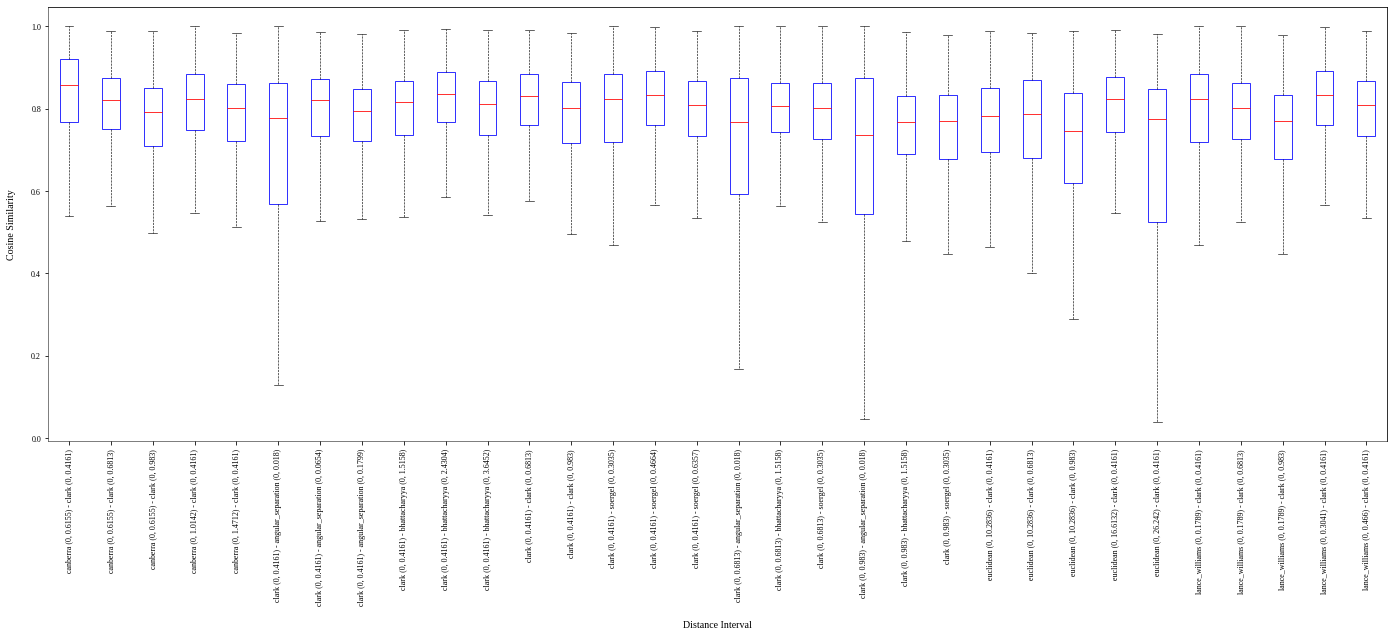

In [14]:
distance_intervals = [
    'euclidean (0, 10.2836)',
    'angular_separation (0, 0.018)',
    'bhattacharyya (0, 1.5158)',
    'canberra (0, 0.6155)',
    'clark (0, 0.4161)',
    'lance_williams (0, 0.1789)',
    'soergel (0, 0.3035)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('clark', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Clark 25th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (cl_p25_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Clark 25th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (cl_p25_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

##### *50th Percentile*

<br>*Cosine Similarity Between Graphs (Clark 50th Percentile)*

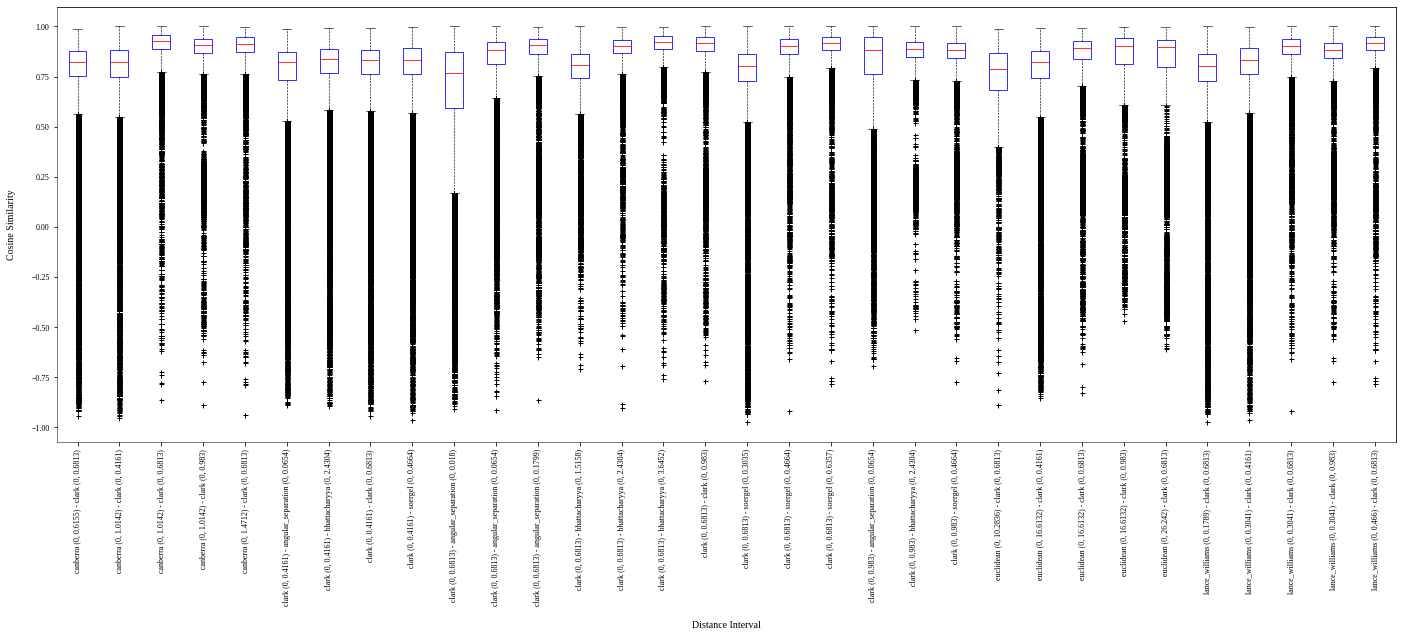

<br>*Cosine Similarity Between Graphs (Clark 50th Percentile) - without outliter*

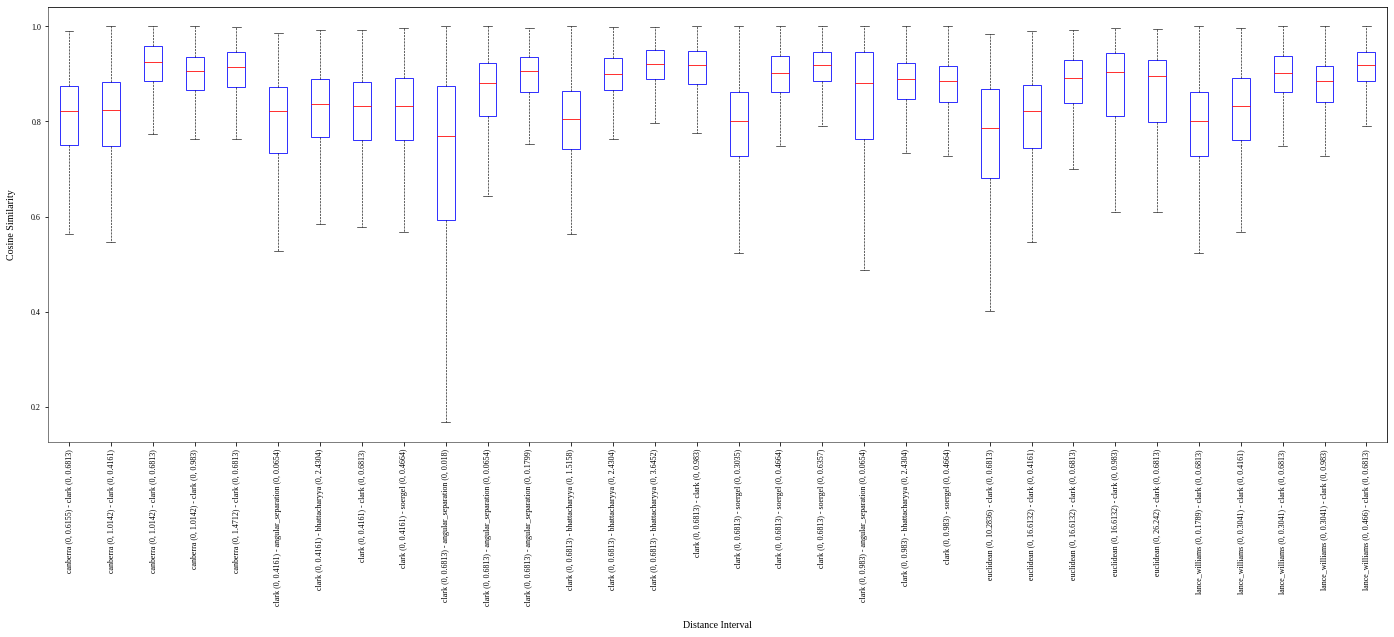

In [15]:
distance_intervals = [
    'euclidean (0, 16.6132)',
    'angular_separation (0, 0.0654)',
    'bhattacharyya (0, 2.4304)',
    'canberra (0, 1.0142)',
    'clark (0, 0.6813)',
    'lance_williams (0, 0.3041)',
    'soergel (0, 0.4664)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('clark', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Clark 50th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (cl_p50_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Clark 50th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (cl_p50_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

##### *75th Percentile*

<br>*Cosine Similarity Between Graphs (Clark 75th Percentile)*

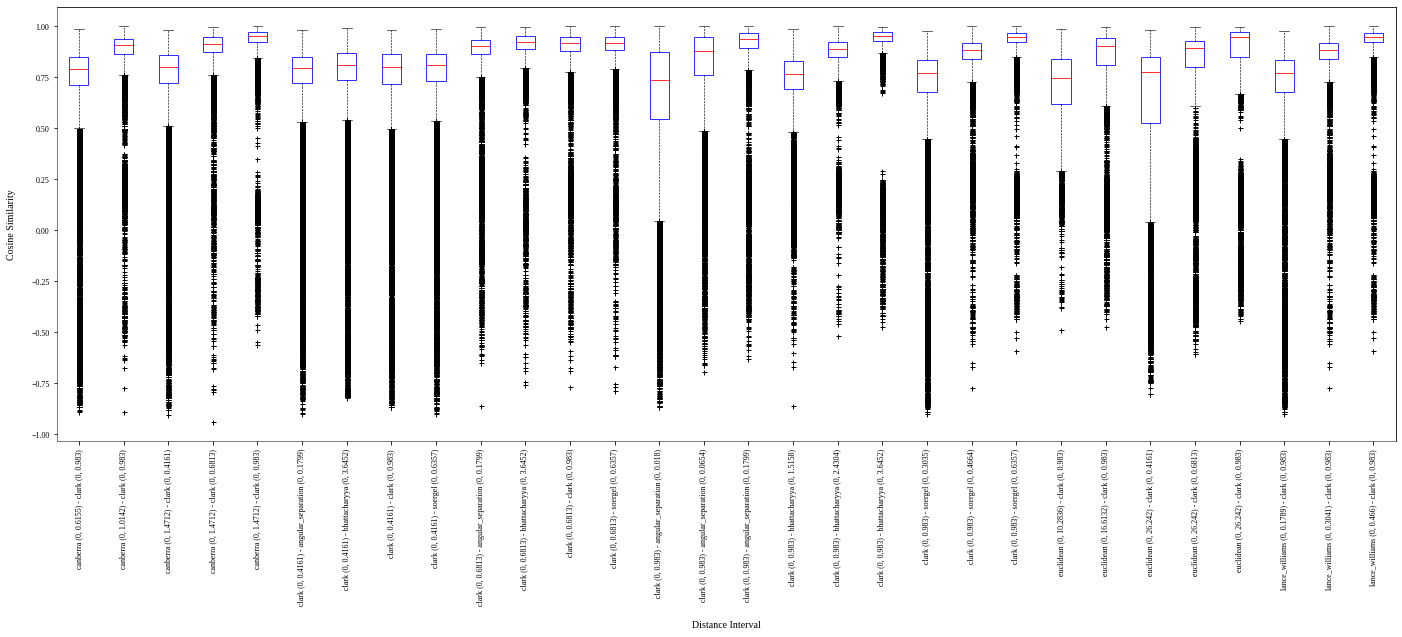

<br>*Cosine Similarity Between Graphs (Clark 75th Percentile) - without outliter*

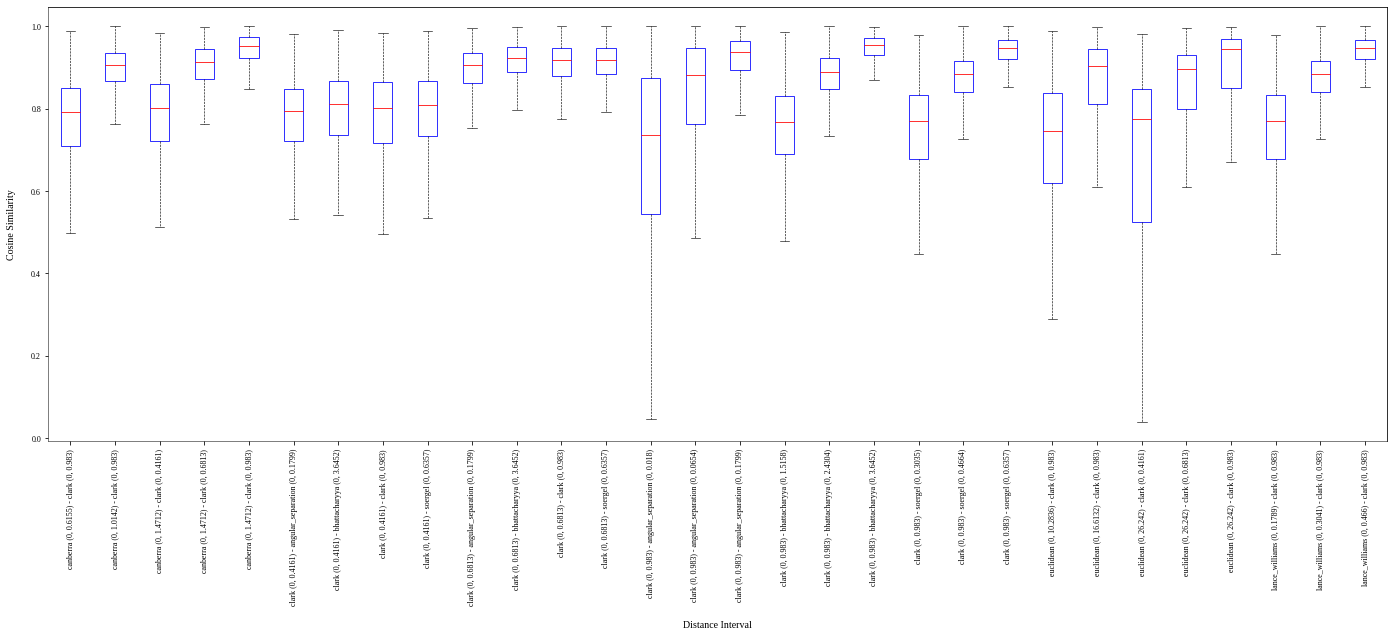

In [16]:
distance_intervals = [
    'euclidean (0, 26.242)',
    'angular_separation (0, 0.1799)',
    'bhattacharyya (0, 3.6452)',
    'canberra (0, 1.4712)',
    'clark (0, 0.983)',
    'euclidean (0, 466)',
    'soergel (0, 0.6357)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('clark', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Clark 75th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (cl_p75_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Clark 75th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (cl_p75_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

#### **Angular Separation**

##### *25th Percentile*

<br>*Cosine Similarity Between Graphs (Angular Separation 25th Percentile)*

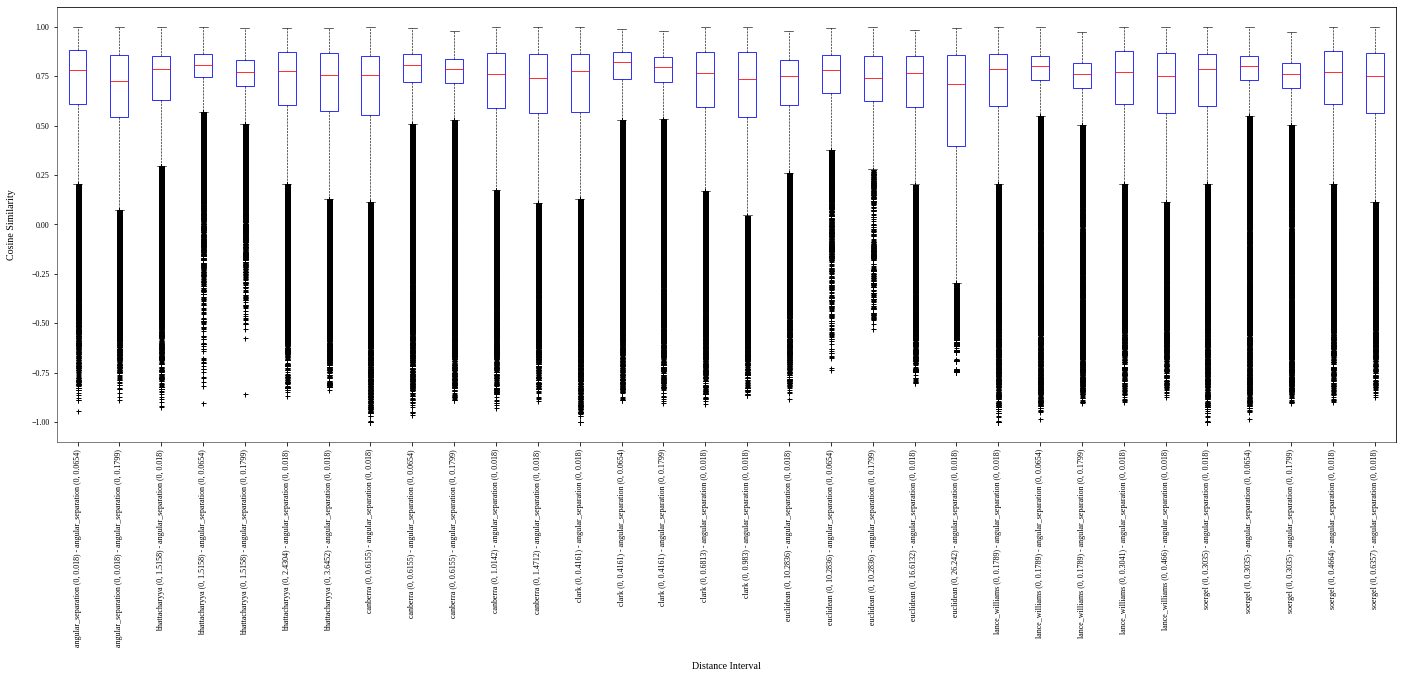

<br>*Cosine Similarity Between Graphs (Angular Separation 25th Percentile) - without outliter*

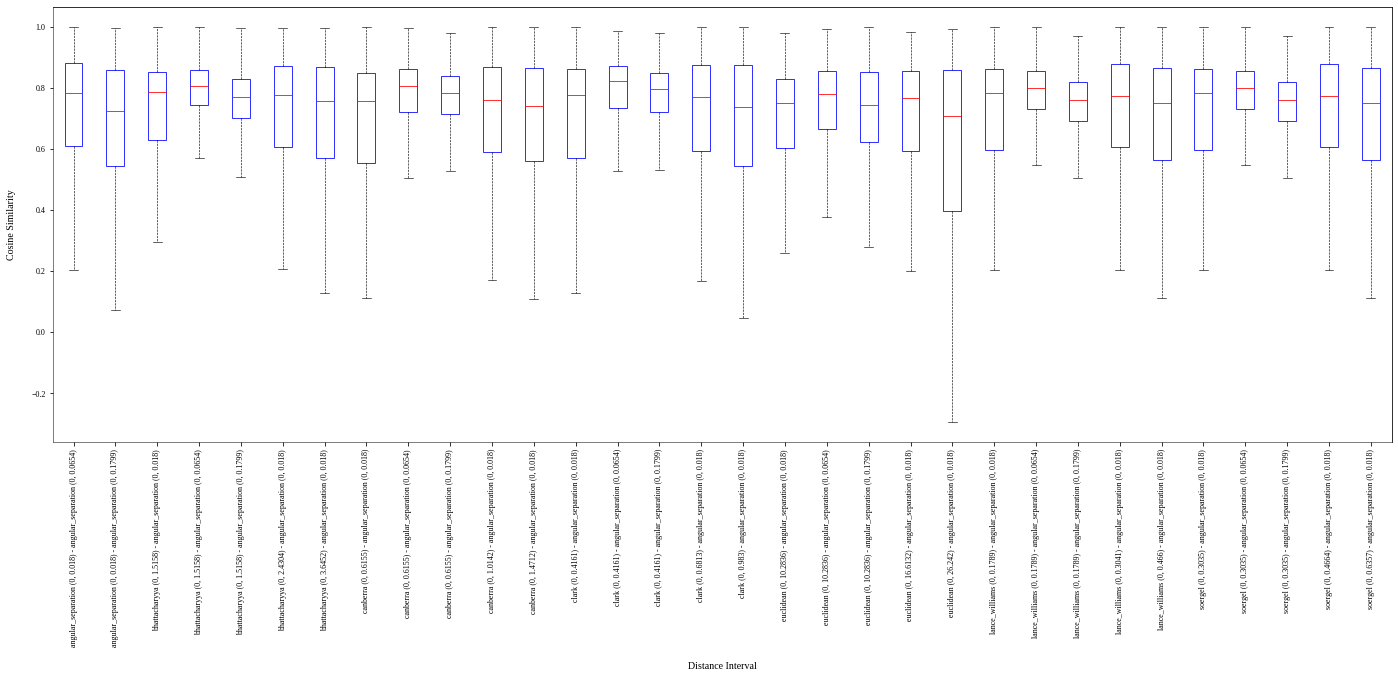

In [17]:
distance_intervals = [
    'euclidean (0, 10.2836)',
    'angular_separation (0, 0.018)',
    'bhattacharyya (0, 1.5158)',
    'canberra (0, 0.6155)',
    'clark (0, 0.4161)',
    'lance_williams (0, 0.1789)',
    'soergel (0, 0.3035)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('angular_separation', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Angular Separation 25th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (as_p25_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Angular Separation 25th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (as_p25_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

##### *50th Percentile*

<br>*Cosine Similarity Between Graphs (Angular Separation 50th Percentile)*

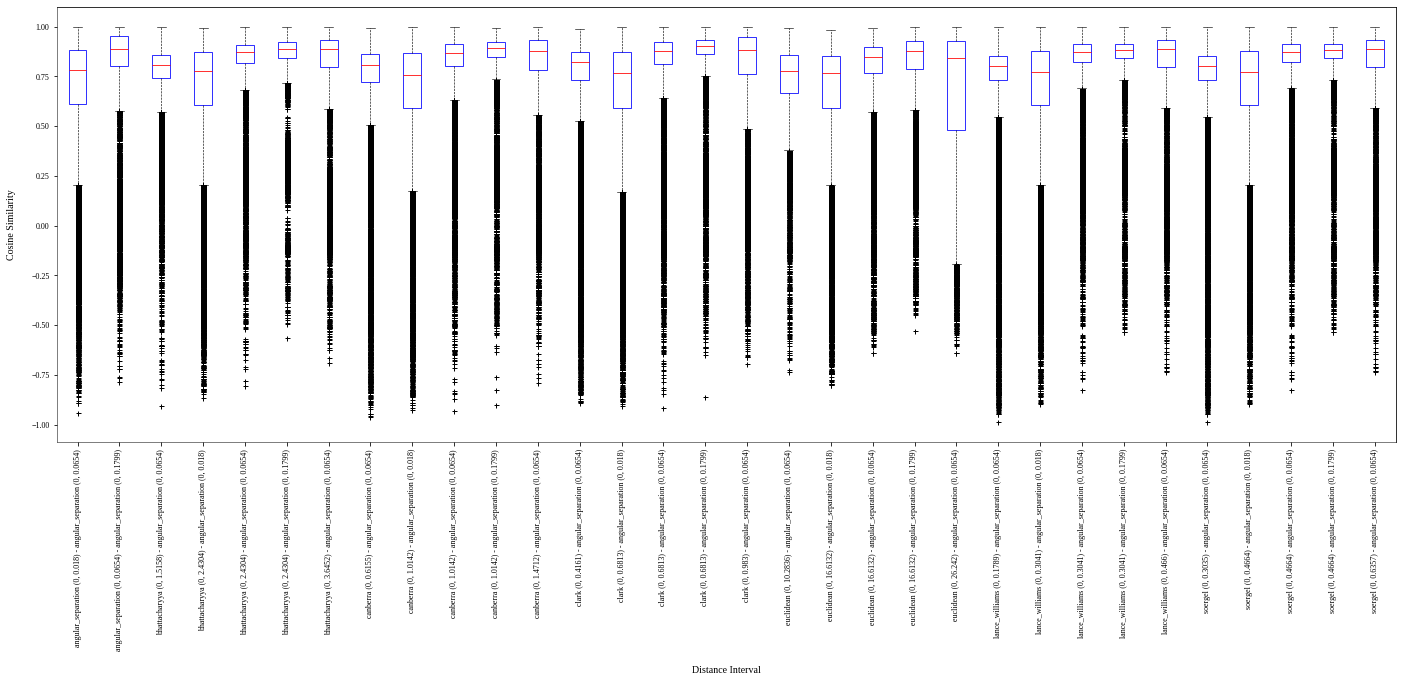

<br>*Cosine Similarity Between Graphs (Angular Separation 50th Percentile) - without outliter*

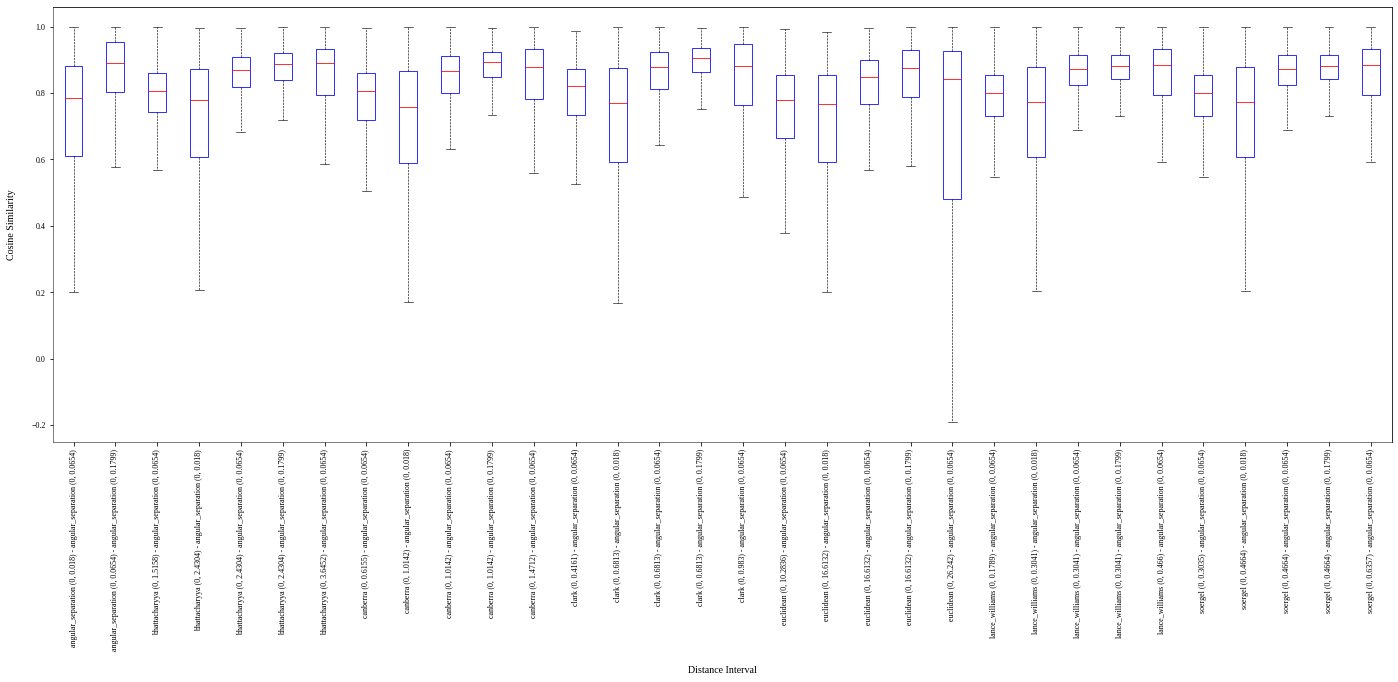

In [18]:
distance_intervals = [
    'euclidean (0, 16.6132)',
    'angular_separation (0, 0.0654)',
    'bhattacharyya (0, 2.4304)',
    'canberra (0, 1.0142)',
    'clark (0, 0.6813)',
    'lance_williams (0, 0.3041)',
    'soergel (0, 0.4664)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('angular_separation', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Angular Separation 50th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (as_p50_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Angular Separation 50th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (as_p50_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

##### *75th Percentile*

<br>*Cosine Similarity Between Graphs (Angular Separation 75th Percentile)*

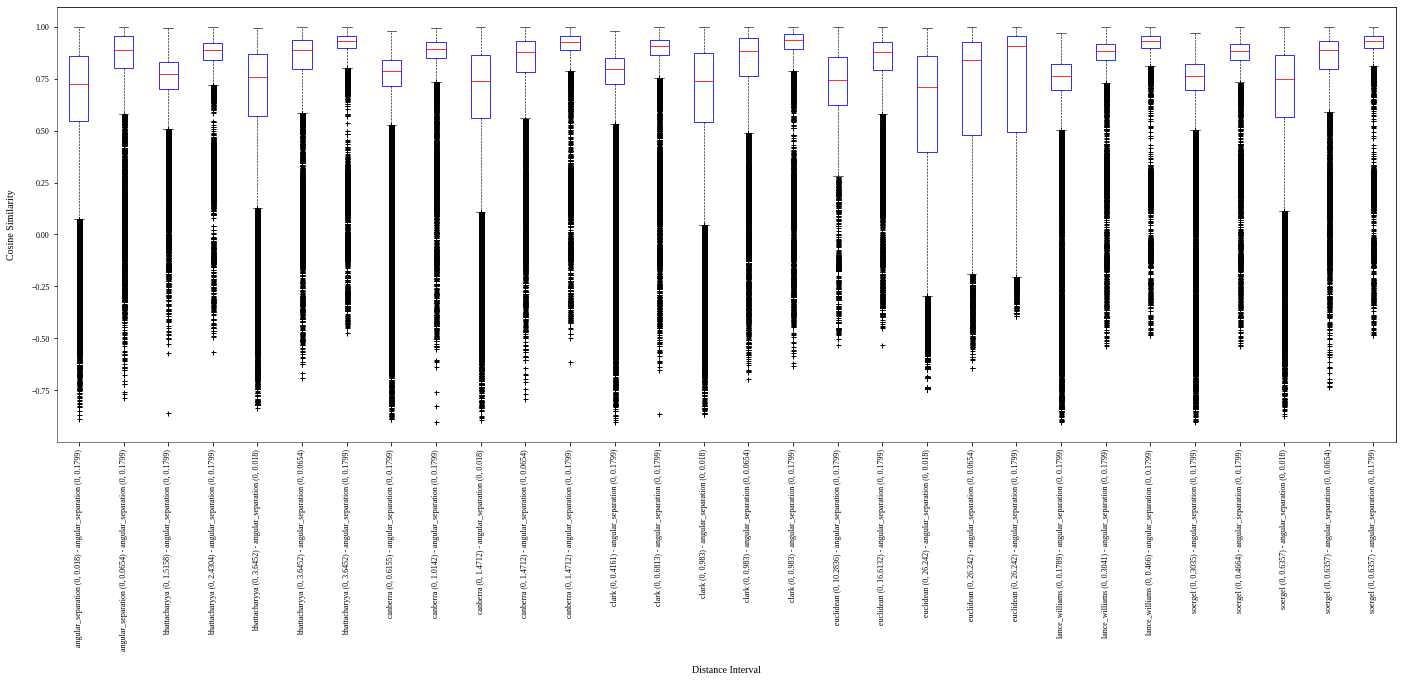

<br>*Cosine Similarity Between Graphs (Angular Separation 75th Percentile) - without outliter*

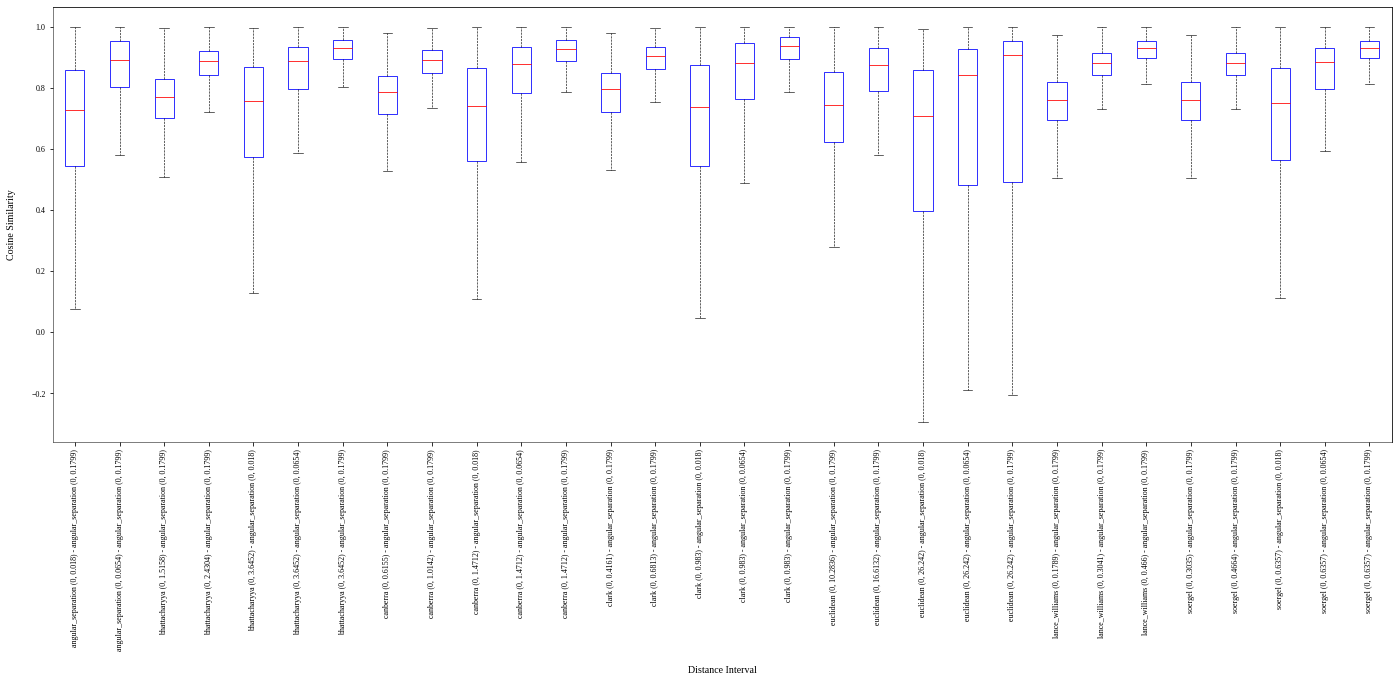

In [19]:
distance_intervals = [
    'euclidean (0, 26.242)',
    'angular_separation (0, 0.1799)',
    'bhattacharyya (0, 3.6452)',
    'canberra (0, 1.4712)',
    'clark (0, 0.983)',
    'euclidean (0, 466)',
    'soergel (0, 0.6357)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('angular_separation', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Angular Separation 75th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (as_p75_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Angular Separation 75th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (as_p75_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

#### **Lance Williams**

##### *25th Percentile*

<br>*Cosine Similarity Between Graphs (Lance Williams 25th Percentile)*

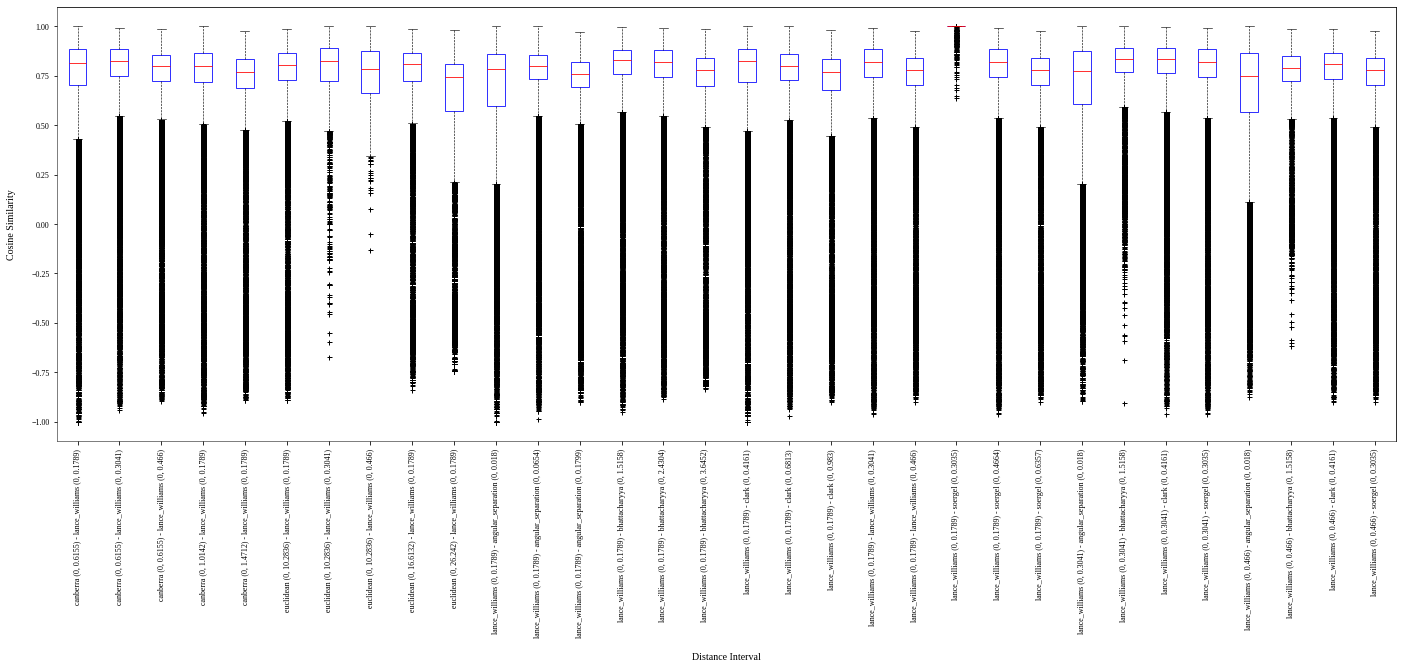

<br>*Cosine Similarity Between Graphs (Lance Williams 25th Percentile) - without outliter*

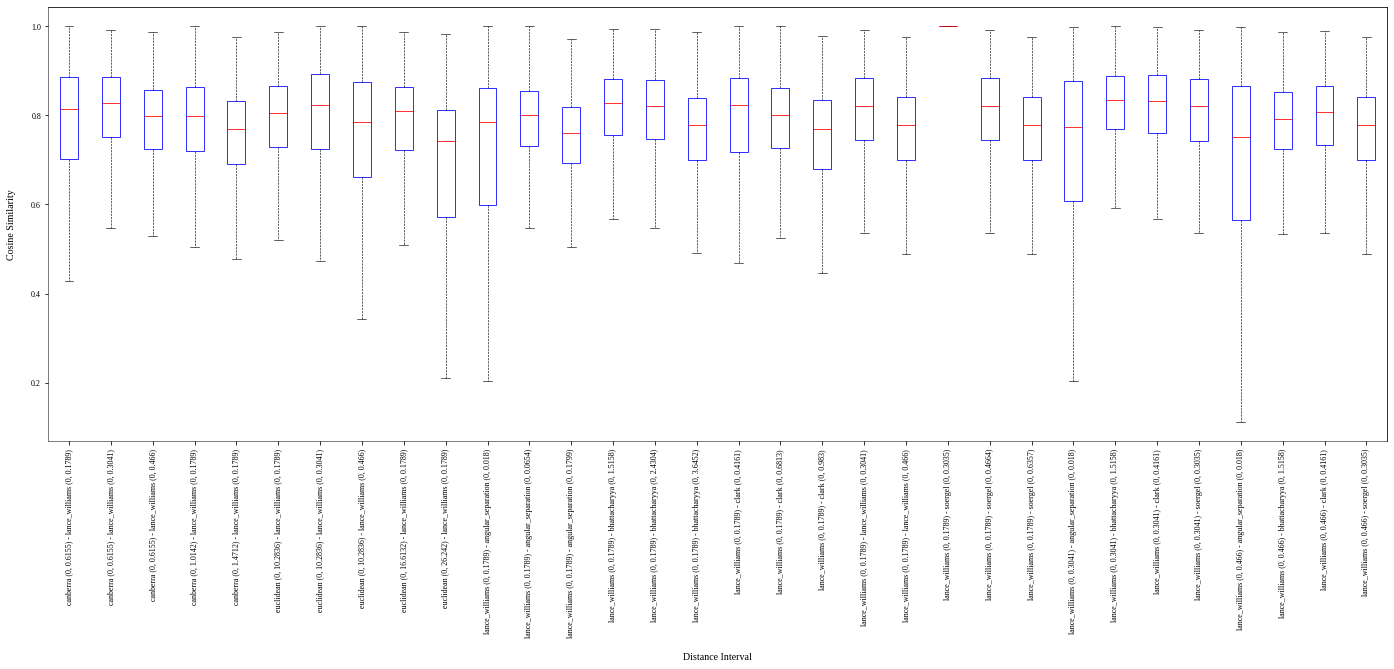

In [20]:
distance_intervals = [
    'euclidean (0, 10.2836)',
    'angular_separation (0, 0.018)',
    'bhattacharyya (0, 1.5158)',
    'canberra (0, 0.6155)',
    'clark (0, 0.4161)',
    'lance_williams (0, 0.1789)',
    'soergel (0, 0.3035)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('lance_williams', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Lance Williams 25th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (lw_p25_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Lance Williams 25th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (lw_p25_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

##### *50th Percentile*

<br>*Cosine Similarity Between Graphs (Lance Williams 50th Percentile)*

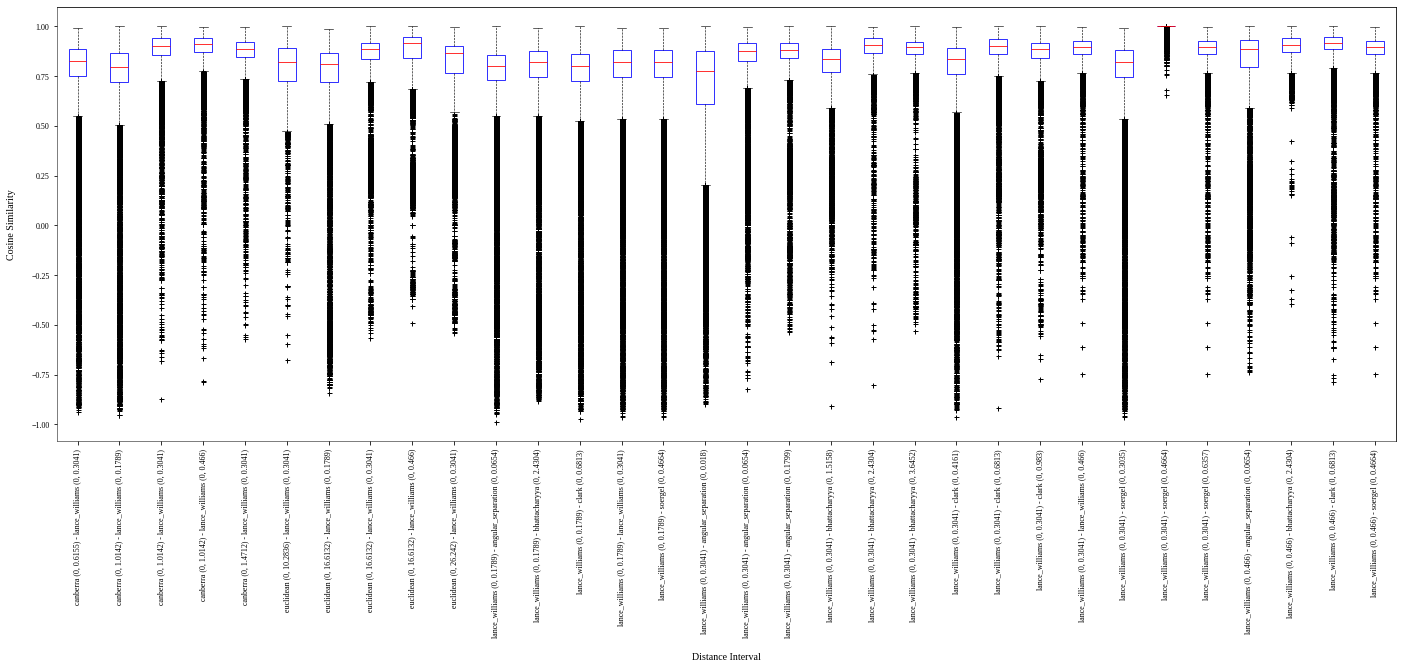

<br>*Cosine Similarity Between Graphs (Lance Williams 50th Percentile) - without outliter*

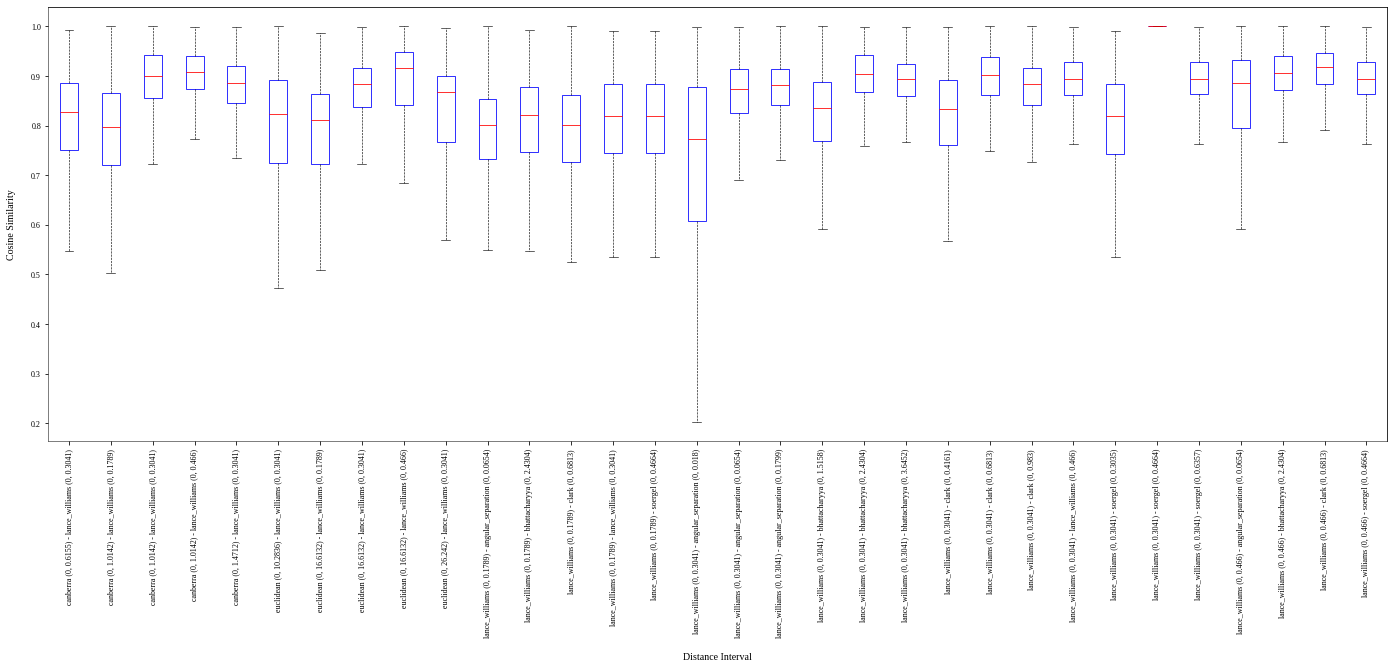

In [21]:
distance_intervals = [
    'euclidean (0, 16.6132)',
    'angular_separation (0, 0.0654)',
    'bhattacharyya (0, 2.4304)',
    'canberra (0, 1.0142)',
    'clark (0, 0.6813)',
    'lance_williams (0, 0.3041)',
    'soergel (0, 0.4664)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('lance_williams', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Lance Williams 50th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (lw_p50_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Lance Williams 50th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (lw_p50_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)

##### *75th Percentile*

<br>*Cosine Similarity Between Graphs (Lance Williams 75th Percentile)*

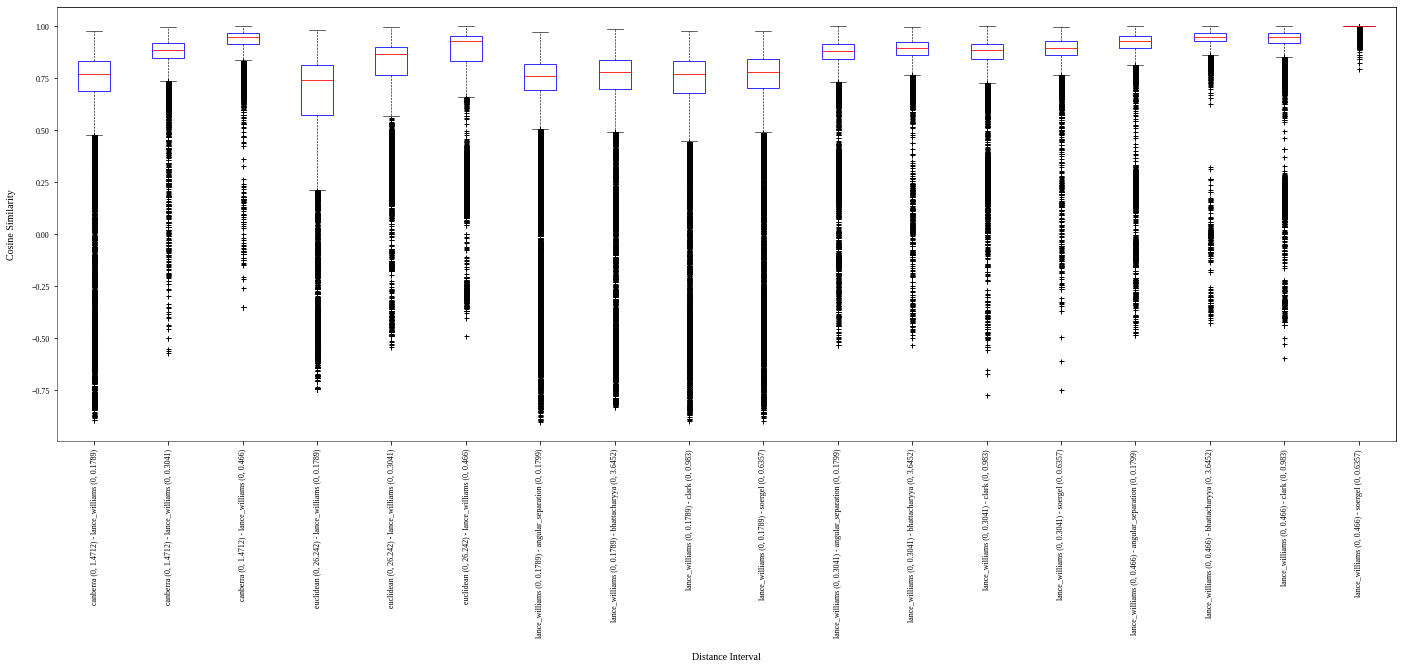

<br>*Cosine Similarity Between Graphs (Lance Williams 75th Percentile) - without outliter*

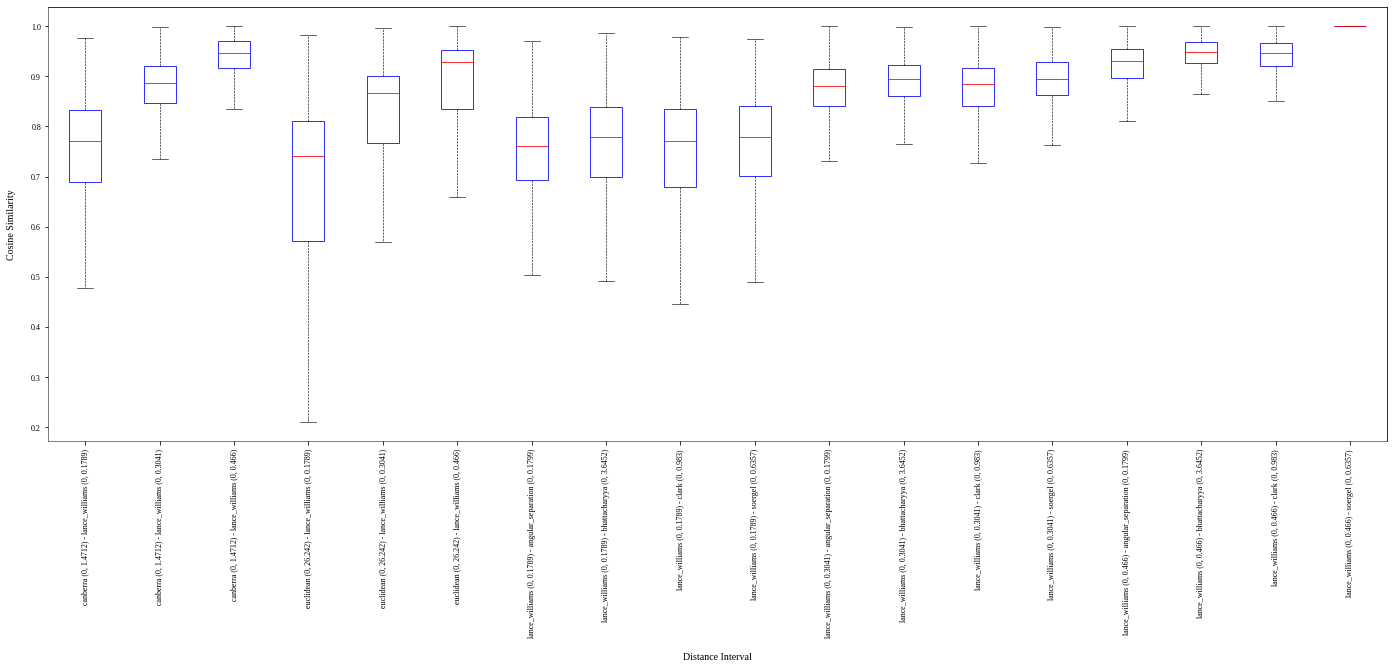

In [22]:
distance_intervals = [
    'euclidean (0, 26.242)',
    'angular_separation (0, 0.1799)',
    'bhattacharyya (0, 3.6452)',
    'canberra (0, 1.4712)',
    'clark (0, 0.983)',
    'euclidean (0, 466)',
    'soergel (0, 0.6357)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('lance_williams', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Lance Williams 75th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (lw_p75_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Lance Williams 75th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (lw_p75_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)

#### **Soergel**

##### *25th Percentile*

<br>*Cosine Similarity Between Graphs (Soergel 25th Percentile)*

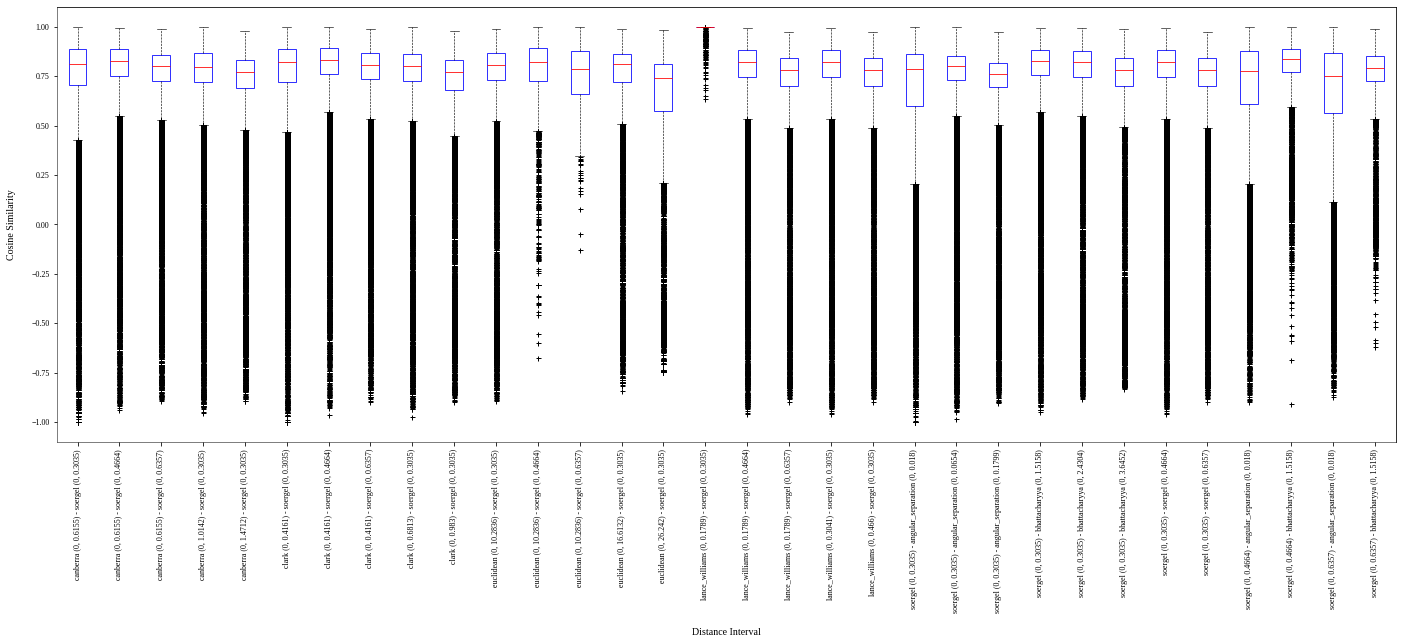

<br>*Cosine Similarity Between Graphs (Soergel 25th Percentile) - without outliter*

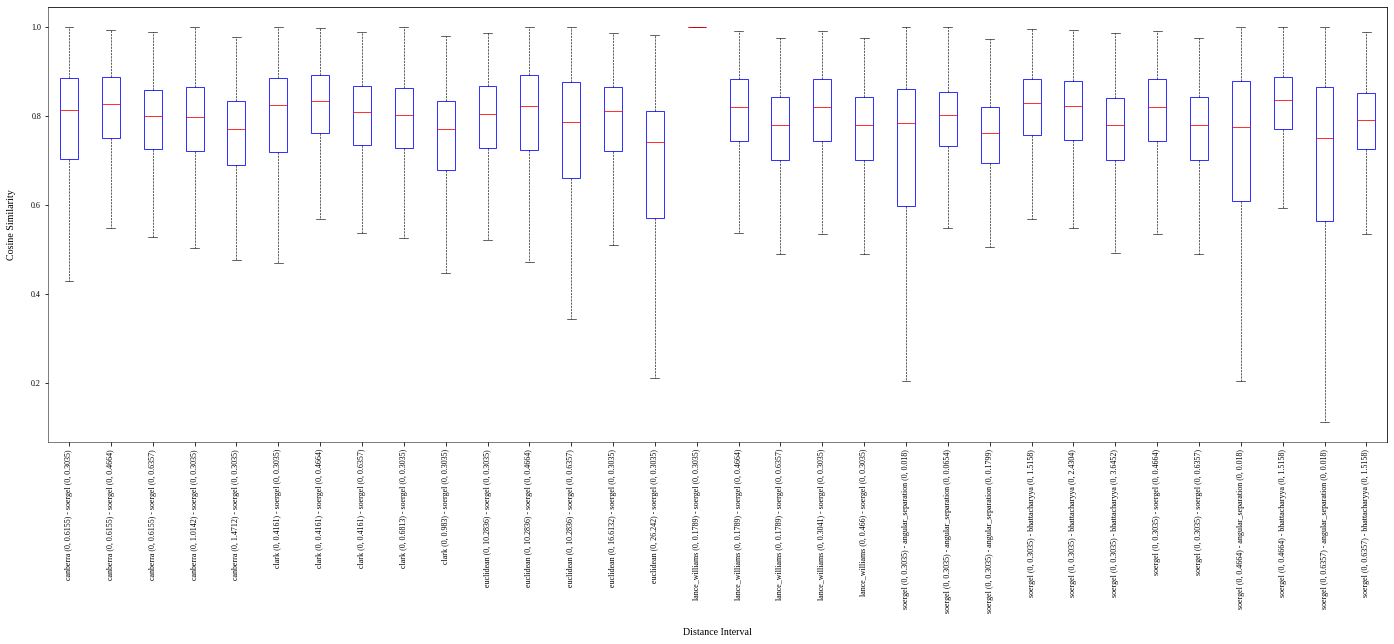

In [23]:
distance_intervals = [
    'euclidean (0, 10.2836)',
    'angular_separation (0, 0.018)',
    'bhattacharyya (0, 1.5158)',
    'canberra (0, 0.6155)',
    'clark (0, 0.4161)',
    'lance_williams (0, 0.1789)',
    'soergel (0, 0.3035)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('soergel', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Soergel 25th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (so_p25_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Soergel 25th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (so_p25_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

##### *50th Percentile*

<br>*Cosine Similarity Between Graphs (Soergel 50th Percentile)*

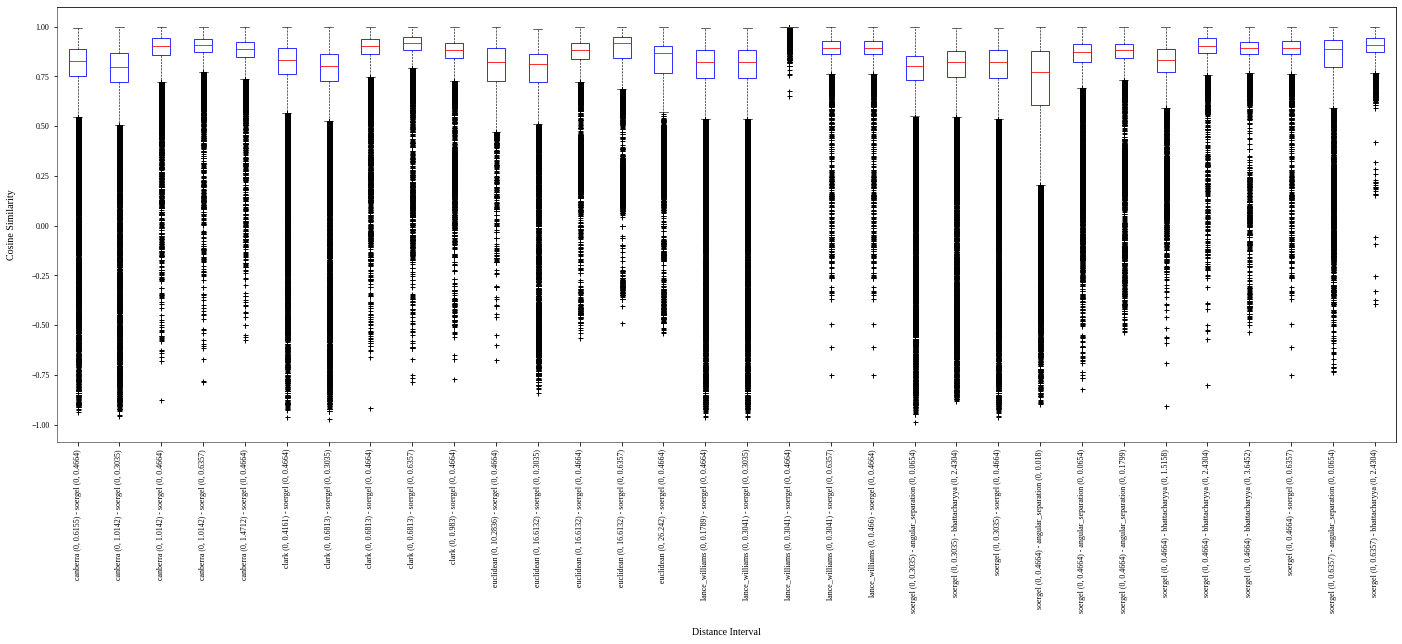

<br>*Cosine Similarity Between Graphs (Soergel 50th Percentile) - without outliter*

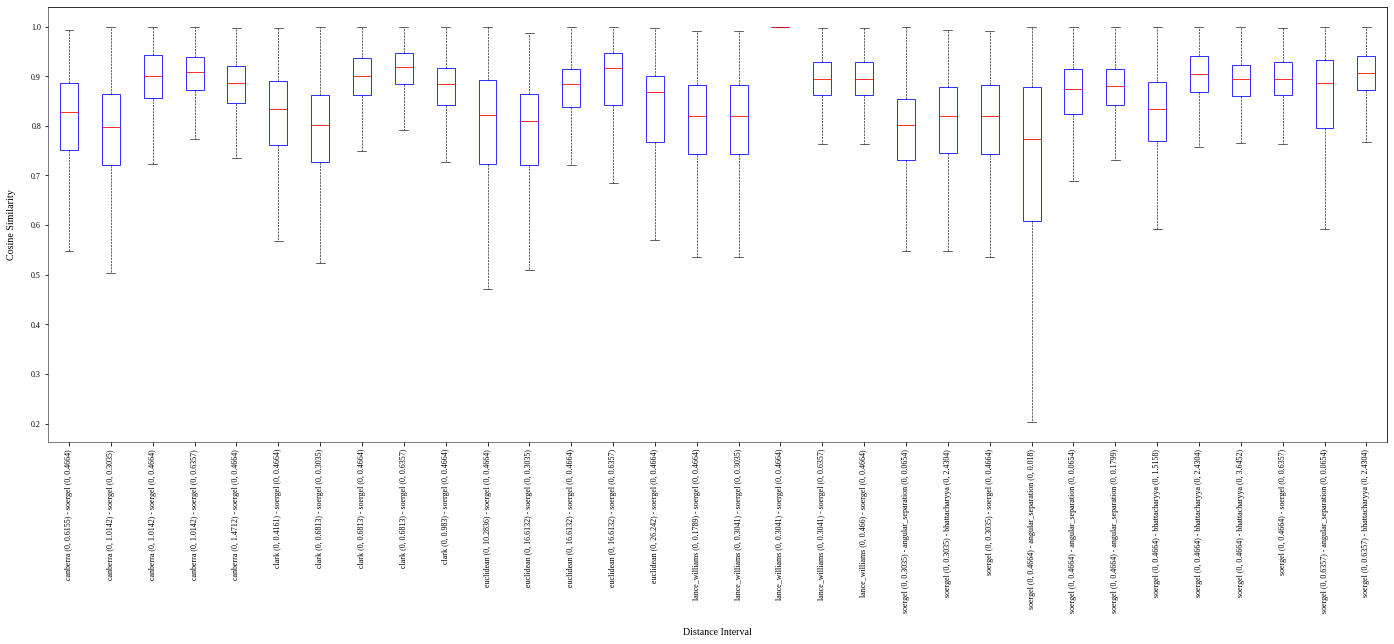

In [24]:
distance_intervals = [
    'euclidean (0, 16.6132)',
    'angular_separation (0, 0.0654)',
    'bhattacharyya (0, 2.4304)',
    'canberra (0, 1.0142)',
    'clark (0, 0.6813)',
    'lance_williams (0, 0.3041)',
    'soergel (0, 0.4664)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('soergel', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Soergel 50th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (so_p50_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Soergel 50th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (so_p50_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

##### *75th Percentile*

<br>*Cosine Similarity Between Graphs (Soergel 75th Percentile)*

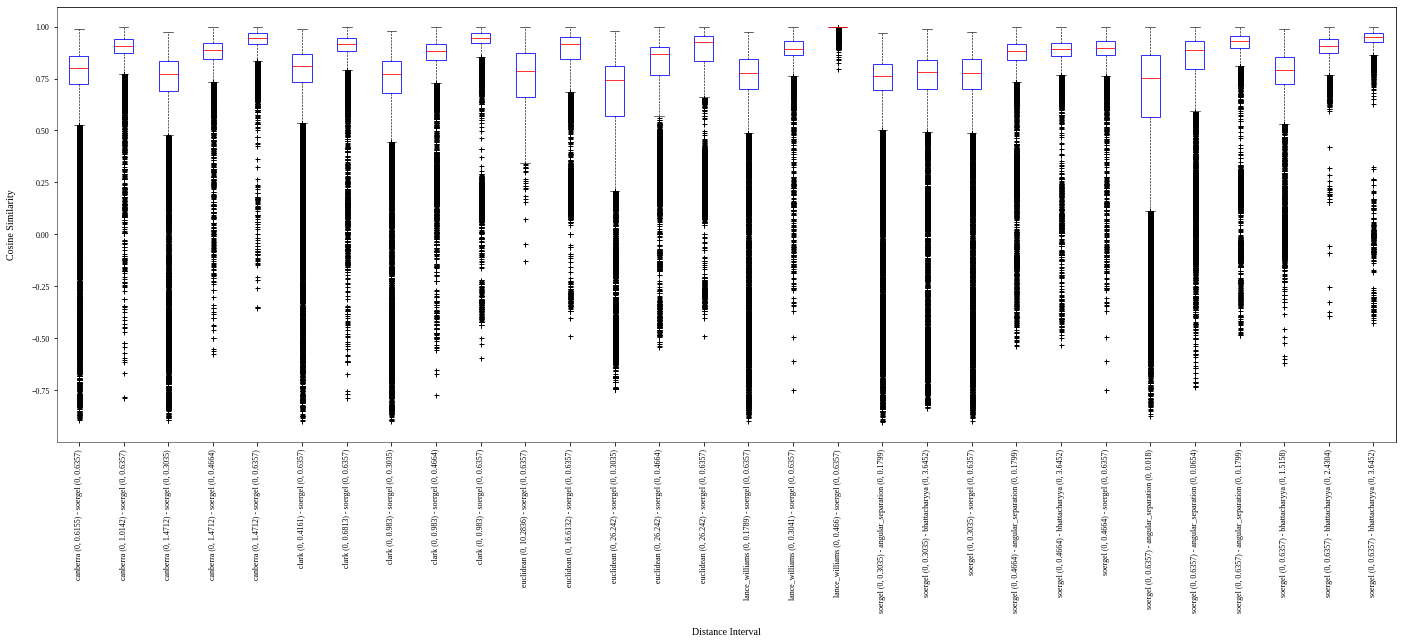

<br>*Cosine Similarity Between Graphs (Soergel 75th Percentile) - without outliter*

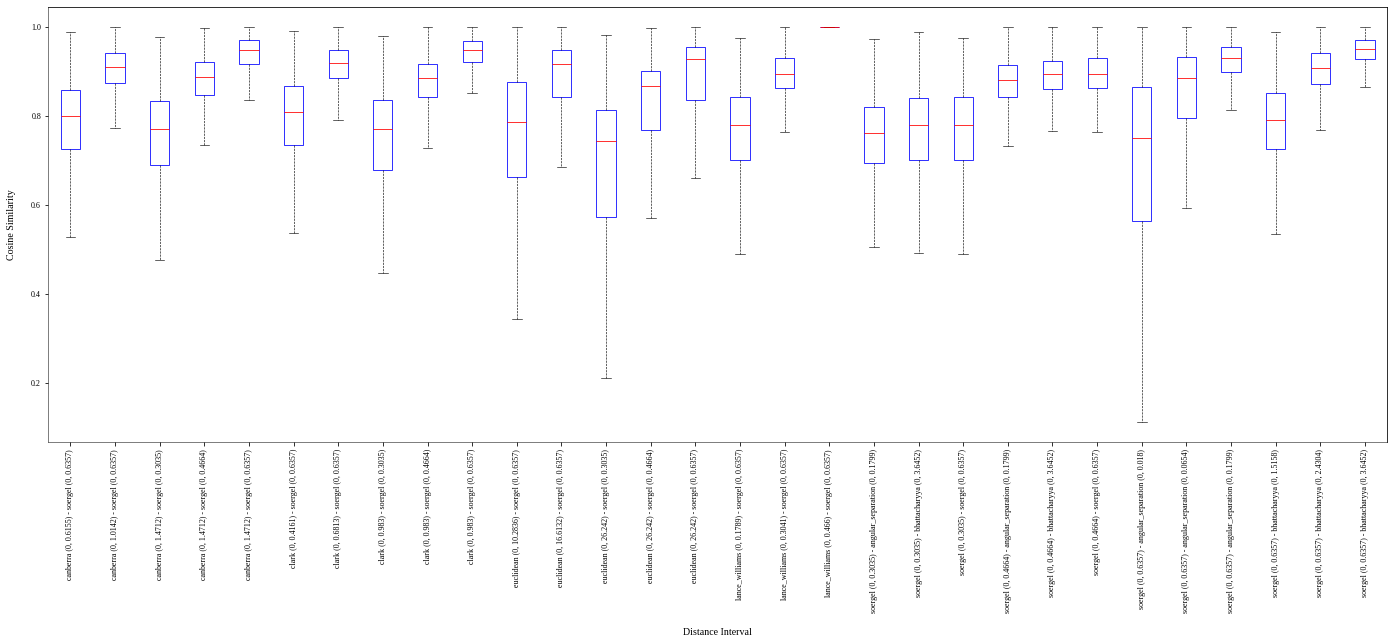

In [25]:
distance_intervals = [
    'euclidean (0, 26.242)',
    'angular_separation (0, 0.1799)',
    'bhattacharyya (0, 3.6452)',
    'canberra (0, 1.4712)',
    'clark (0, 0.983)',
    'euclidean (0, 466)',
    'soergel (0, 0.6357)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_eu = data[data['distance_interval_comb'].str.contains('soergel', na=True)].dropna(subset=['cosine_similarity']).copy()
data_eu = data_eu[data_eu['distance_interval_comb'].str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval_comb'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Cosine Similarity'
fig_size=(24, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>*Cosine Similarity Between Graphs (Soergel 75th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (so_p75_distance_intervals) -boxplot")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity Between Graphs (Soergel 75th Percentile) - without outliter*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity Between Graphs (so_p75_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_eu, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()